#  Logistics Data Warehouse — Full Business Analysis

**Senior Data Analyst Report** | Logistics Domain

---

## Analysis Structure
1. **Setup & Data Loading** — Connect to SQL Server, load Gold layer tables
2. **Revenue & Profitability Analysis** — Revenue trends, top customers, route profitability
3. **Operational Efficiency** — Trip metrics, fuel efficiency, idle time
4. **Fleet & Maintenance** — Maintenance costs, downtime, truck age impact
5. **Safety Analysis** — Incident trends, cost analysis, preventability
6. **Delivery Performance** — On-time rates, detention time, facility analysis
7. **Driver Performance** — Revenue per driver, efficiency, safety records
8. **Executive Summary & KPIs**

## Data Warehouse Star Schema

```mermaid
erDiagram
    dim_driver ||--o{ fact_trip : "driver_key"
    dim_truck ||--o{ fact_trip : "truck_key"
    dim_trailer ||--o{ fact_trip : "trailer_key"
    dim_customer ||--o{ fact_trip : "customer_key"
    dim_route ||--o{ fact_trip : "route_key"
    dim_date ||--o{ fact_trip : "dispatch_date_key"

    dim_driver ||--o{ fact_fuel_purchase : "driver_key"
    dim_truck ||--o{ fact_fuel_purchase : "truck_key"
    dim_date ||--o{ fact_fuel_purchase : "purchase_date_key"

    dim_truck ||--o{ fact_maintenance : "truck_key"
    dim_date ||--o{ fact_maintenance : "maintenance_date_key"

    dim_driver ||--o{ fact_safety : "driver_key"
    dim_truck ||--o{ fact_safety : "truck_key"
    dim_date ||--o{ fact_safety : "incident_date_key"

    dim_facility ||--o{ fact_delivery : "facility_key"
    dim_driver ||--o{ fact_delivery : "driver_key"
    dim_truck ||--o{ fact_delivery : "truck_key"
    dim_customer ||--o{ fact_delivery : "customer_key"
    dim_route ||--o{ fact_delivery : "route_key"
    dim_date ||--o{ fact_delivery : "event_date_key"
```


---
## Phase 1: Setup & Data Loading

In [1]:
# ============================================================
# SETUP
# ============================================================
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'

# Colors
COLORS = {
    'primary': '#2563EB',
    'secondary': '#7C3AED',
    'success': '#059669',
    'danger': '#DC2626',
    'warning': '#D97706',
    'info': '#0891B2',
    'palette': ['#2563EB', '#7C3AED', '#059669', '#DC2626', '#D97706', '#0891B2', '#DB2777', '#4F46E5']
}

print(' Libraries loaded successfully')

 Libraries loaded successfully


In [2]:
# ============================================================
# DATABASE CONNECTION
# ============================================================
conn_str = (
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=localhost\\SQLEXPRESS;'
    'DATABASE=logistics_dwh;'
    'Trusted_Connection=yes;'
)
conn = pyodbc.connect(conn_str)
print(' Connected to logistics_dwh on localhost\\SQLEXPRESS')

 Connected to logistics_dwh on localhost\SQLEXPRESS


In [3]:
# ============================================================
# LOAD ALL GOLD LAYER TABLES
# ============================================================

# Dimensions
dim_driver = pd.read_sql('SELECT * FROM gold.dim_driver', conn)
dim_truck = pd.read_sql('SELECT * FROM gold.dim_truck', conn)
dim_trailer = pd.read_sql('SELECT * FROM gold.dim_trailer', conn)
dim_customer = pd.read_sql('SELECT * FROM gold.dim_customer', conn)
dim_facility = pd.read_sql('SELECT * FROM gold.dim_facility', conn)
dim_route = pd.read_sql('SELECT * FROM gold.dim_route', conn)
dim_date = pd.read_sql('SELECT * FROM gold.dim_date', conn)

# Facts
fact_trip = pd.read_sql('SELECT * FROM gold.fact_trip', conn)
fact_fuel = pd.read_sql('SELECT * FROM gold.fact_fuel_purchase', conn)
fact_maint = pd.read_sql('SELECT * FROM gold.fact_maintenance', conn)
fact_safety = pd.read_sql('SELECT * FROM gold.fact_safety', conn)
fact_delivery = pd.read_sql('SELECT * FROM gold.fact_delivery', conn)

print(' All Gold layer tables loaded:')
for name, df in [('dim_driver', dim_driver), ('dim_truck', dim_truck), ('dim_trailer', dim_trailer),
                  ('dim_customer', dim_customer), ('dim_facility', dim_facility), ('dim_route', dim_route),
                  ('dim_date', dim_date), ('fact_trip', fact_trip), ('fact_fuel', fact_fuel),
                  ('fact_maint', fact_maint), ('fact_safety', fact_safety), ('fact_delivery', fact_delivery)]:
    print(f'   {name:25s} → {len(df):>10,} rows')

 All Gold layer tables loaded:
   dim_driver                →        150 rows
   dim_truck                 →        120 rows
   dim_trailer               →        180 rows
   dim_customer              →        200 rows
   dim_facility              →         50 rows
   dim_route                 →         58 rows
   dim_date                  →      4,018 rows
   fact_trip                 →     85,410 rows
   fact_fuel                 →    196,442 rows
   fact_maint                →      2,920 rows
   fact_safety               →        170 rows
   fact_delivery             →    170,820 rows


In [4]:
# ============================================================
# PREPARE ENRICHED DATASETS
# ============================================================

# Enrich fact_trip with dimension data
trips = (
    fact_trip
    .merge(dim_driver[['driver_key','full_name','home_terminal','employment_status','cdl_class','years_experience']], on='driver_key', how='left')
    .merge(dim_truck[['truck_key','make','model_year','fuel_type','truck_age_years','status']], on='truck_key', how='left', suffixes=('','_truck'))
    .merge(dim_customer[['customer_key','customer_name','customer_type','primary_freight_type']], on='customer_key', how='left')
    .merge(dim_route[['route_key','origin_city','origin_state','destination_city','destination_state','typical_distance_miles','lane_description']], on='route_key', how='left')
    .merge(dim_date[['date_key','full_date','year','quarter','month','month_name','day_name','is_weekend','year_month']], left_on='dispatch_date_key', right_on='date_key', how='left')
)

# Enrich fact_fuel
fuel = (
    fact_fuel
    .merge(dim_driver[['driver_key','full_name']], on='driver_key', how='left')
    .merge(dim_truck[['truck_key','make','model_year','fuel_type','truck_age_years']], on='truck_key', how='left')
    .merge(dim_date[['date_key','full_date','year','quarter','month','year_month']], left_on='purchase_date_key', right_on='date_key', how='left')
)

# Enrich fact_maintenance
maint = (
    fact_maint
    .merge(dim_truck[['truck_key','make','model_year','truck_age_years']], on='truck_key', how='left')
    .merge(dim_date[['date_key','full_date','year','quarter','month','year_month']], left_on='maintenance_date_key', right_on='date_key', how='left')
)

# Enrich fact_safety
safety = (
    fact_safety
    .merge(dim_driver[['driver_key','full_name','years_experience']], on='driver_key', how='left')
    .merge(dim_truck[['truck_key','make','model_year','truck_age_years']], on='truck_key', how='left')
    .merge(dim_date[['date_key','full_date','year','quarter','month','year_month']], left_on='incident_date_key', right_on='date_key', how='left')
)

# Enrich fact_delivery
delivery = (
    fact_delivery
    .merge(dim_facility[['facility_key','facility_name','facility_type','city','state']], on='facility_key', how='left')
    .merge(dim_driver[['driver_key','full_name']], on='driver_key', how='left')
    .merge(dim_customer[['customer_key','customer_name']], on='customer_key', how='left')
    .merge(dim_route[['route_key','lane_description']], on='route_key', how='left')
    .merge(dim_date[['date_key','full_date','year','quarter','month','year_month']], left_on='event_date_key', right_on='date_key', how='left')
)

print(' Enriched datasets ready')
print(f'   trips:    {trips.shape}')
print(f'   fuel:     {fuel.shape}')
print(f'   maint:    {maint.shape}')
print(f'   safety:   {safety.shape}')
print(f'   delivery: {delivery.shape}')

 Enriched datasets ready
   trips:    (85410, 53)
   fuel:     (196442, 24)
   maint:    (2920, 23)
   safety:   (170, 29)
   delivery: (170820, 31)


---
## Phase 2: Revenue & Profitability Analysis

### Business Questions:
1. What is the total revenue, and how has it trended over time?
2. Which are the top 10 customers by revenue?
3. What is the revenue distribution by customer type?
4. Which routes (lanes) generate the most revenue?
5. What is the average revenue per trip, and how does it vary by quarter?
6. What is the revenue vs. fuel cost profitability trend?

 Total Revenue:          $ 298,621,428.94
 Total Trips:                     85,410
 Average Revenue/Trip:   $       3,496.33


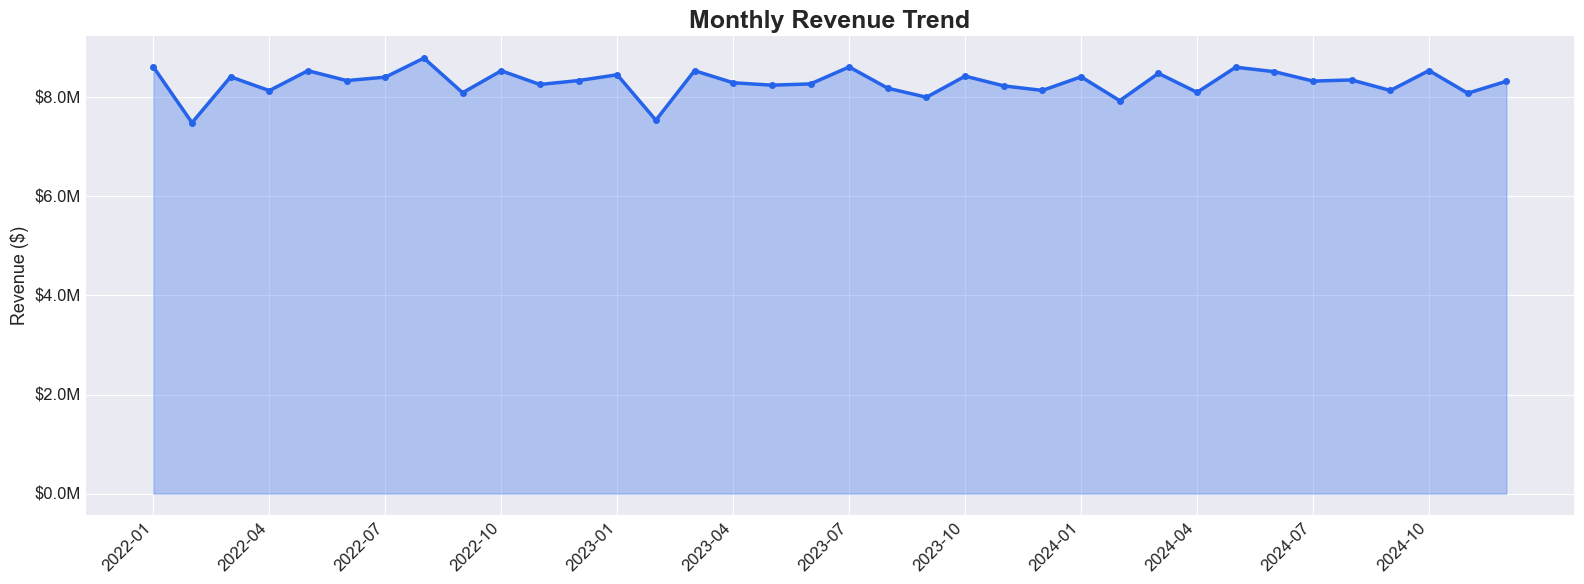

In [5]:
# ============================================================
# Q1: TOTAL REVENUE & MONTHLY TREND
# ============================================================
total_revenue = trips['total_revenue'].sum()
total_trips = len(trips)
avg_revenue = trips['total_revenue'].mean()

print(f' Total Revenue:          ${total_revenue:>15,.2f}')
print(f' Total Trips:            {total_trips:>15,}')
print(f' Average Revenue/Trip:   ${avg_revenue:>15,.2f}')

# Monthly revenue trend
monthly_rev = trips.groupby('year_month')['total_revenue'].sum().reset_index()
monthly_rev = monthly_rev.sort_values('year_month')

fig, ax = plt.subplots(figsize=(16, 6))
ax.fill_between(range(len(monthly_rev)), monthly_rev['total_revenue'], alpha=0.3, color=COLORS['primary'])
ax.plot(range(len(monthly_rev)), monthly_rev['total_revenue'], color=COLORS['primary'], linewidth=2.5, marker='o', markersize=4)
ax.set_title('Monthly Revenue Trend', fontsize=18, fontweight='bold')
ax.set_ylabel('Revenue ($)', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_xticks(range(0, len(monthly_rev), 3))
ax.set_xticklabels(monthly_rev['year_month'].iloc[::3], rotation=45, ha='right')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

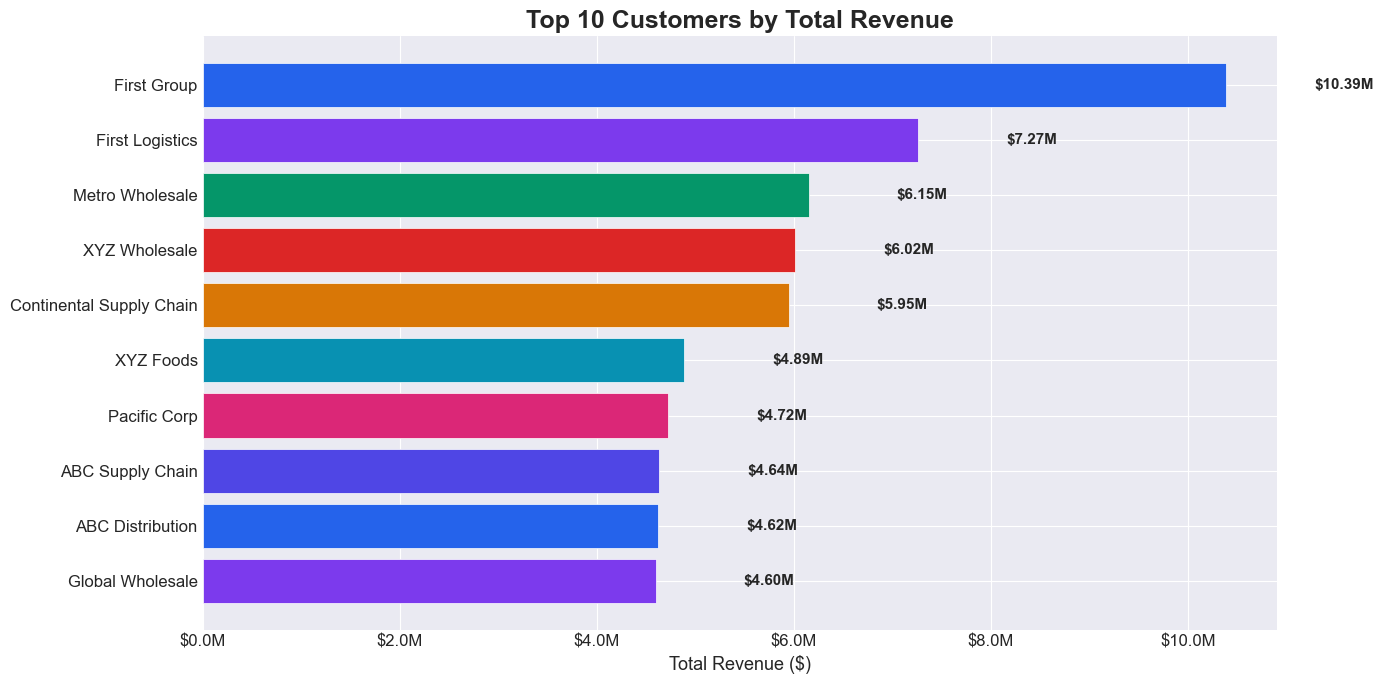

In [6]:
# ============================================================
# Q2: TOP 10 CUSTOMERS BY REVENUE
# ============================================================
top_customers = trips.groupby('customer_name')['total_revenue'].sum().nlargest(10).reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top_customers['customer_name'], top_customers['total_revenue'], color=COLORS['palette'][:10], edgecolor='white', linewidth=0.5)
ax.set_title('Top 10 Customers by Total Revenue', fontsize=18, fontweight='bold')
ax.set_xlabel('Total Revenue ($)', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.invert_yaxis()

for bar, val in zip(bars, top_customers['total_revenue']):
    ax.text(val + total_revenue * 0.003, bar.get_y() + bar.get_height()/2, f'${val/1e6:.2f}M', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

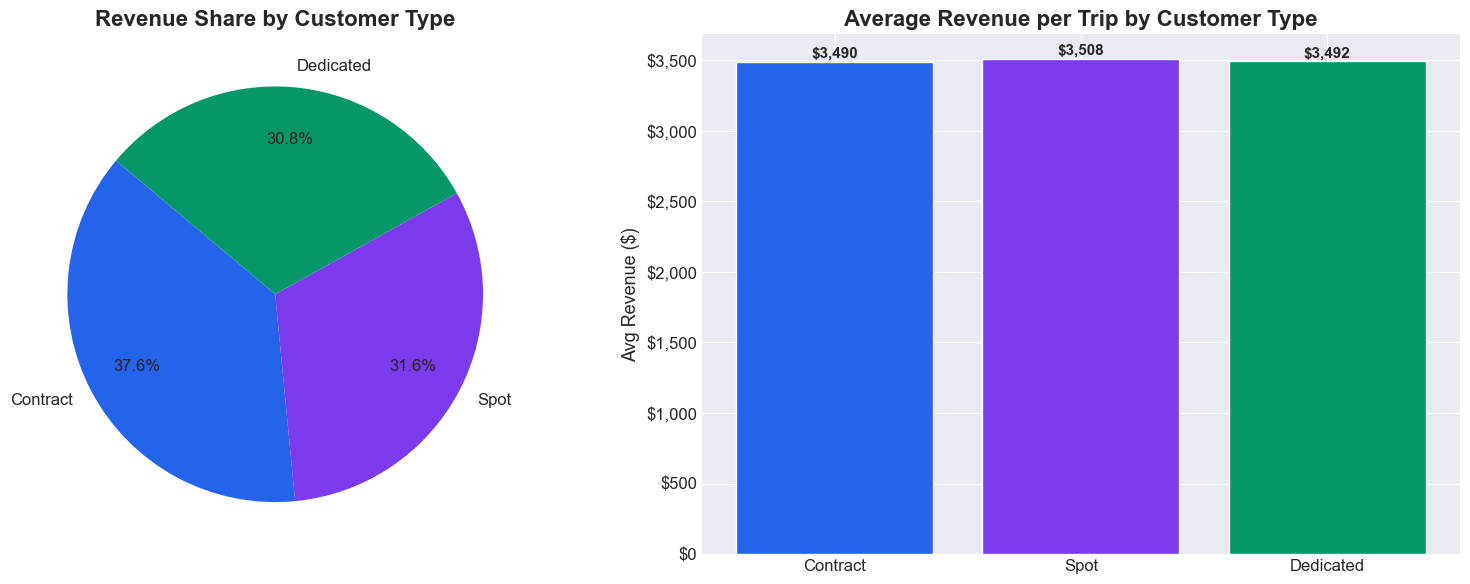

In [7]:
# ============================================================
# Q3: REVENUE BY CUSTOMER TYPE
# ============================================================
rev_by_type = trips.groupby('customer_type').agg(
    total_revenue=('total_revenue', 'sum'),
    trip_count=('trip_key', 'count'),
    avg_revenue=('total_revenue', 'mean')
).reset_index().sort_values('total_revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
axes[0].pie(rev_by_type['total_revenue'], labels=rev_by_type['customer_type'],
            autopct='%1.1f%%', colors=COLORS['palette'], startangle=140,
            textprops={'fontsize': 12}, pctdistance=0.75)
axes[0].set_title('Revenue Share by Customer Type', fontsize=16, fontweight='bold')

# Avg revenue bar
axes[1].bar(rev_by_type['customer_type'], rev_by_type['avg_revenue'], color=COLORS['palette'][:len(rev_by_type)], edgecolor='white')
axes[1].set_title('Average Revenue per Trip by Customer Type', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Avg Revenue ($)', fontsize=13)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for i, v in enumerate(rev_by_type['avg_revenue']):
    axes[1].text(i, v + 30, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

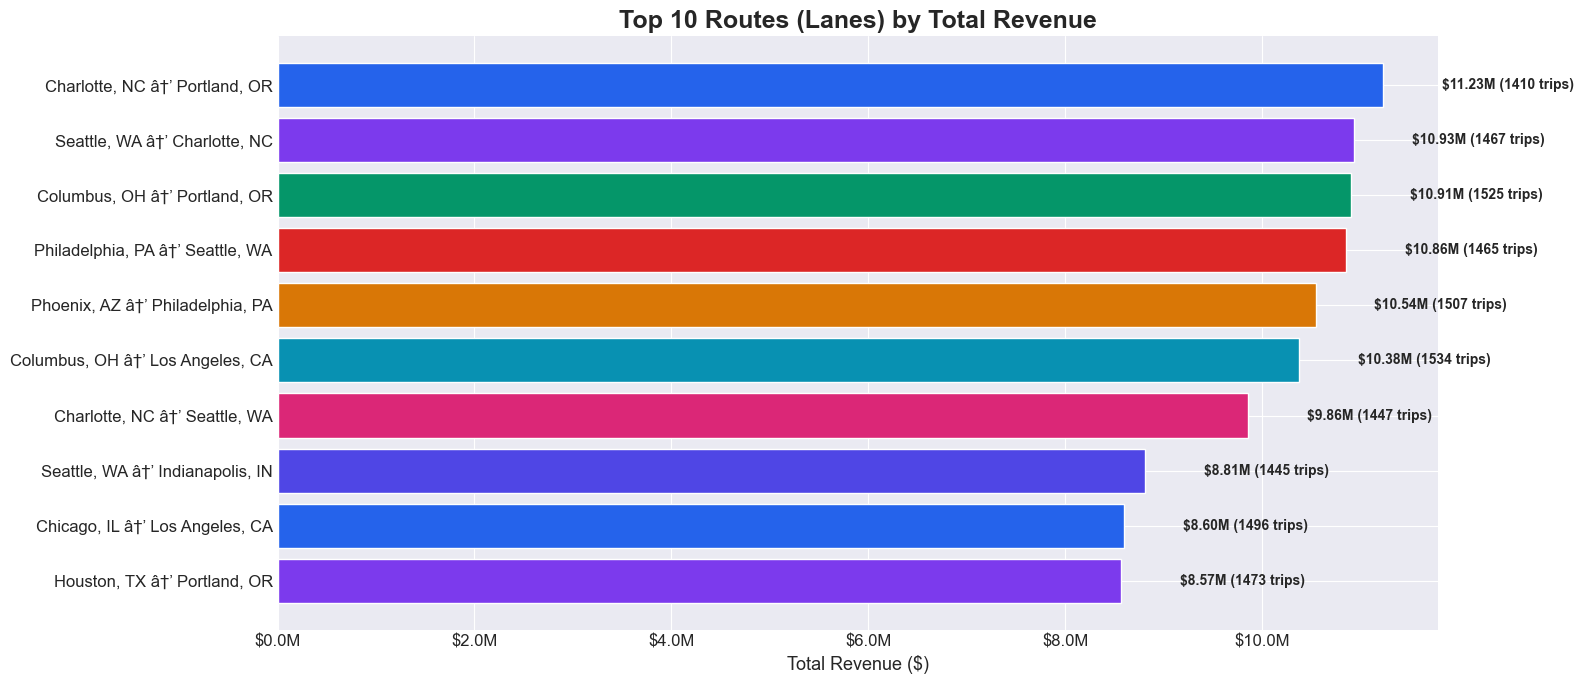

In [8]:
# ============================================================
# Q4: TOP 10 ROUTES BY REVENUE
# ============================================================
top_routes = trips.groupby('lane_description').agg(
    total_revenue=('total_revenue', 'sum'),
    trip_count=('trip_key', 'count'),
    avg_revenue=('total_revenue', 'mean'),
    avg_distance=('actual_distance_miles', 'mean')
).nlargest(10, 'total_revenue').reset_index()

fig, ax = plt.subplots(figsize=(16, 7))
bars = ax.barh(top_routes['lane_description'], top_routes['total_revenue'], color=COLORS['palette'][:10], edgecolor='white')
ax.set_title('Top 10 Routes (Lanes) by Total Revenue', fontsize=18, fontweight='bold')
ax.set_xlabel('Total Revenue ($)', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.invert_yaxis()

for bar, val, cnt in zip(bars, top_routes['total_revenue'], top_routes['trip_count']):
    ax.text(val + total_revenue * 0.002, bar.get_y() + bar.get_height()/2, f'${val/1e6:.2f}M ({cnt} trips)', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

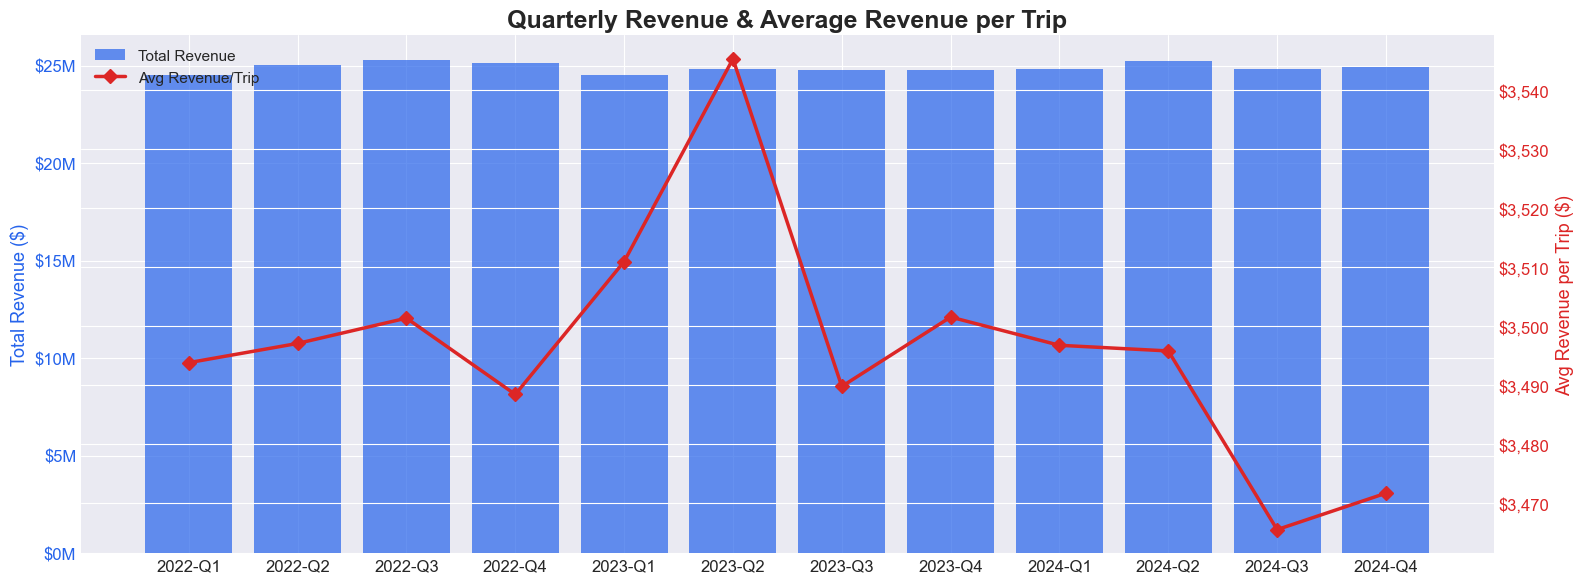

In [9]:
# ============================================================
# Q5: QUARTERLY REVENUE & AVG REVENUE PER TRIP
# ============================================================
quarterly = trips.groupby(['year', 'quarter']).agg(
    total_revenue=('total_revenue', 'sum'),
    trip_count=('trip_key', 'count'),
    avg_revenue=('total_revenue', 'mean')
).reset_index()
quarterly['label'] = quarterly['year'].astype(str) + '-Q' + quarterly['quarter'].astype(str)

fig, ax1 = plt.subplots(figsize=(16, 6))
bars = ax1.bar(quarterly['label'], quarterly['total_revenue'], color=COLORS['primary'], alpha=0.7, label='Total Revenue')
ax1.set_ylabel('Total Revenue ($)', fontsize=13, color=COLORS['primary'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax1.tick_params(axis='y', labelcolor=COLORS['primary'])

ax2 = ax1.twinx()
ax2.plot(quarterly['label'], quarterly['avg_revenue'], color=COLORS['danger'], linewidth=2.5, marker='D', markersize=7, label='Avg Revenue/Trip')
ax2.set_ylabel('Avg Revenue per Trip ($)', fontsize=13, color=COLORS['danger'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.tick_params(axis='y', labelcolor=COLORS['danger'])

ax1.set_title('Quarterly Revenue & Average Revenue per Trip', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

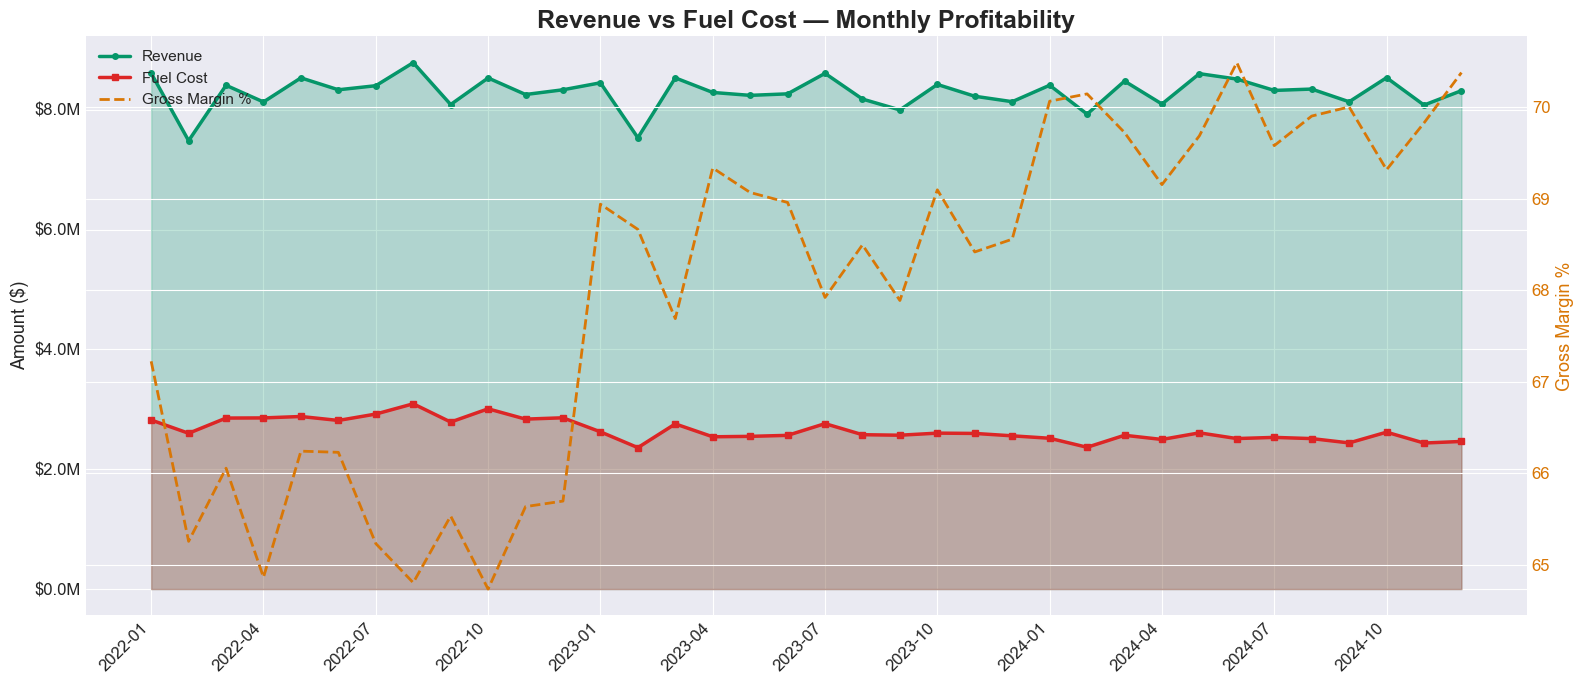


 Overall Gross Margin: 68.0%
   Total Revenue:  $ 298,621,428.94
   Total Fuel Cost: $ 95,592,992.04
   Gross Profit:    $203,028,436.90


In [10]:
# ============================================================
# Q6: REVENUE VS FUEL COST — PROFITABILITY TREND
# ============================================================
monthly_rev_data = trips.groupby('year_month')['total_revenue'].sum().reset_index()
monthly_fuel_data = fuel.groupby('year_month')['total_cost'].sum().reset_index()
profitability = monthly_rev_data.merge(monthly_fuel_data, on='year_month', how='inner')
profitability = profitability.sort_values('year_month')
profitability['gross_margin'] = profitability['total_revenue'] - profitability['total_cost']
profitability['margin_pct'] = (profitability['gross_margin'] / profitability['total_revenue'] * 100)

fig, ax1 = plt.subplots(figsize=(16, 7))
x = range(len(profitability))

ax1.fill_between(x, profitability['total_revenue'], alpha=0.25, color=COLORS['success'])
ax1.plot(x, profitability['total_revenue'], color=COLORS['success'], linewidth=2.5, label='Revenue', marker='o', markersize=4)
ax1.fill_between(x, profitability['total_cost'], alpha=0.25, color=COLORS['danger'])
ax1.plot(x, profitability['total_cost'], color=COLORS['danger'], linewidth=2.5, label='Fuel Cost', marker='s', markersize=4)
ax1.set_ylabel('Amount ($)', fontsize=13)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

ax2 = ax1.twinx()
ax2.plot(x, profitability['margin_pct'], color=COLORS['warning'], linewidth=2, linestyle='--', label='Gross Margin %')
ax2.set_ylabel('Gross Margin %', fontsize=13, color=COLORS['warning'])
ax2.tick_params(axis='y', labelcolor=COLORS['warning'])

ax1.set_title('Revenue vs Fuel Cost — Monthly Profitability', fontsize=18, fontweight='bold')
ax1.set_xticks(range(0, len(profitability), 3))
ax1.set_xticklabels(profitability['year_month'].iloc[::3], rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

print(f'\n Overall Gross Margin: {(total_revenue - fuel["total_cost"].sum()) / total_revenue * 100:.1f}%')
print(f'   Total Revenue:  ${total_revenue:>15,.2f}')
print(f'   Total Fuel Cost: ${fuel["total_cost"].sum():>14,.2f}')
print(f'   Gross Profit:    ${total_revenue - fuel["total_cost"].sum():>14,.2f}')

---
## Phase 3: Operational Efficiency Analysis

### Business Questions:
7. What is the distribution of trip distances and durations?
8. What is the fleet-wide fuel efficiency (MPG) and how does it vary by truck make?
9. How much idle time is being wasted, and which terminals have the worst idle rates?
10. Is there a correlation between trip distance and revenue?

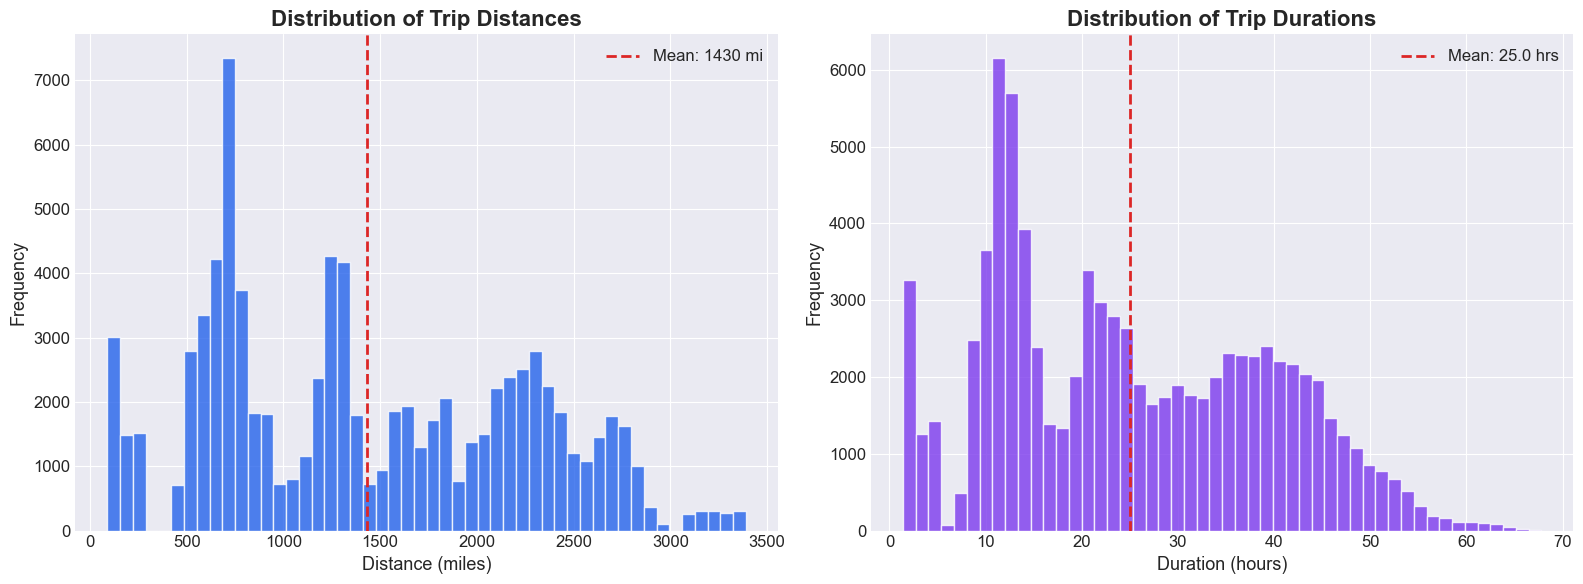

 Trip Statistics:
   Avg Distance:       1,430 miles
   Avg Duration:        25.0 hours
   Avg Speed:           57.5 mph


In [11]:
# ============================================================
# Q7: TRIP DISTANCE & DURATION DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(trips['actual_distance_miles'].dropna(), bins=50, color=COLORS['primary'], edgecolor='white', alpha=0.8)
axes[0].axvline(trips['actual_distance_miles'].mean(), color=COLORS['danger'], linestyle='--', linewidth=2, label=f'Mean: {trips["actual_distance_miles"].mean():.0f} mi')
axes[0].set_title('Distribution of Trip Distances', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Distance (miles)', fontsize=13)
axes[0].set_ylabel('Frequency', fontsize=13)
axes[0].legend(fontsize=12)

axes[1].hist(trips['actual_duration_hours'].dropna(), bins=50, color=COLORS['secondary'], edgecolor='white', alpha=0.8)
axes[1].axvline(trips['actual_duration_hours'].mean(), color=COLORS['danger'], linestyle='--', linewidth=2, label=f'Mean: {trips["actual_duration_hours"].mean():.1f} hrs')
axes[1].set_title('Distribution of Trip Durations', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Duration (hours)', fontsize=13)
axes[1].set_ylabel('Frequency', fontsize=13)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

print(f' Trip Statistics:')
print(f'   Avg Distance:  {trips["actual_distance_miles"].mean():>10,.0f} miles')
print(f'   Avg Duration:  {trips["actual_duration_hours"].mean():>10,.1f} hours')
print(f'   Avg Speed:     {(trips["actual_distance_miles"] / trips["actual_duration_hours"]).mean():>10,.1f} mph')

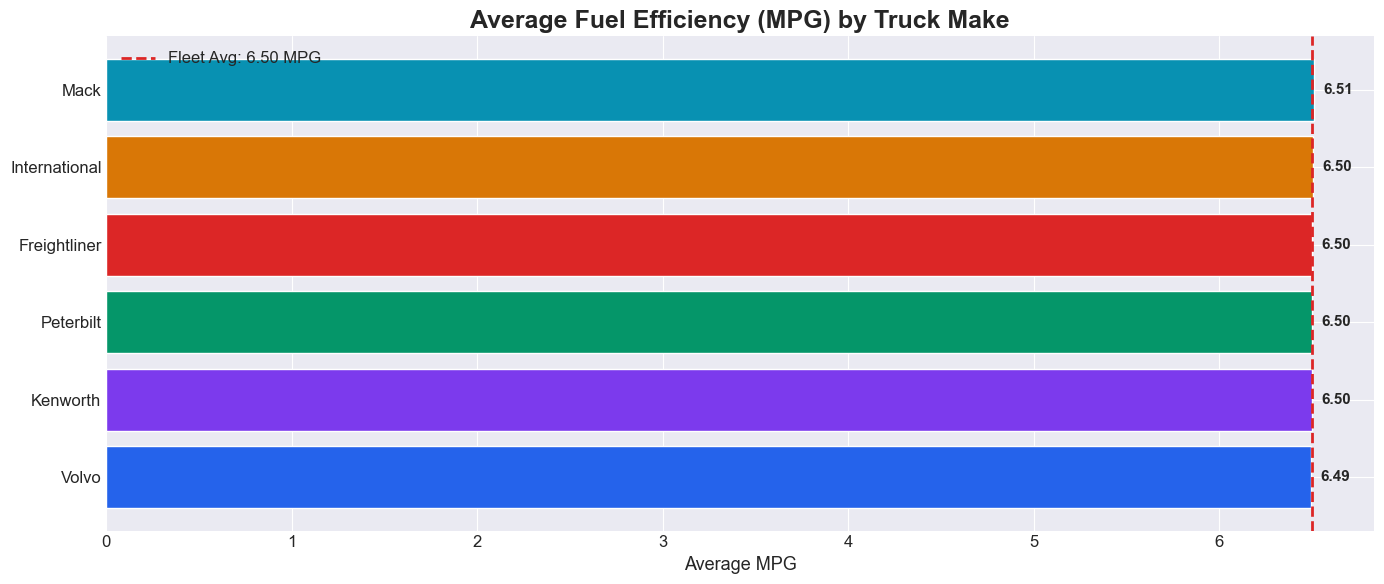

In [12]:
# ============================================================
# Q8: FUEL EFFICIENCY (MPG) BY TRUCK MAKE
# ============================================================
mpg_by_make = trips.groupby('make')['average_mpg'].agg(['mean','median','count']).reset_index()
mpg_by_make.columns = ['make', 'avg_mpg', 'median_mpg', 'trip_count']
mpg_by_make = mpg_by_make.sort_values('avg_mpg', ascending=True)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(mpg_by_make['make'], mpg_by_make['avg_mpg'], color=COLORS['palette'][:len(mpg_by_make)], edgecolor='white')
ax.axvline(trips['average_mpg'].mean(), color=COLORS['danger'], linestyle='--', linewidth=2, label=f'Fleet Avg: {trips["average_mpg"].mean():.2f} MPG')
ax.set_title('Average Fuel Efficiency (MPG) by Truck Make', fontsize=18, fontweight='bold')
ax.set_xlabel('Average MPG', fontsize=13)
ax.legend(fontsize=12)

for bar, val in zip(bars, mpg_by_make['avg_mpg']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

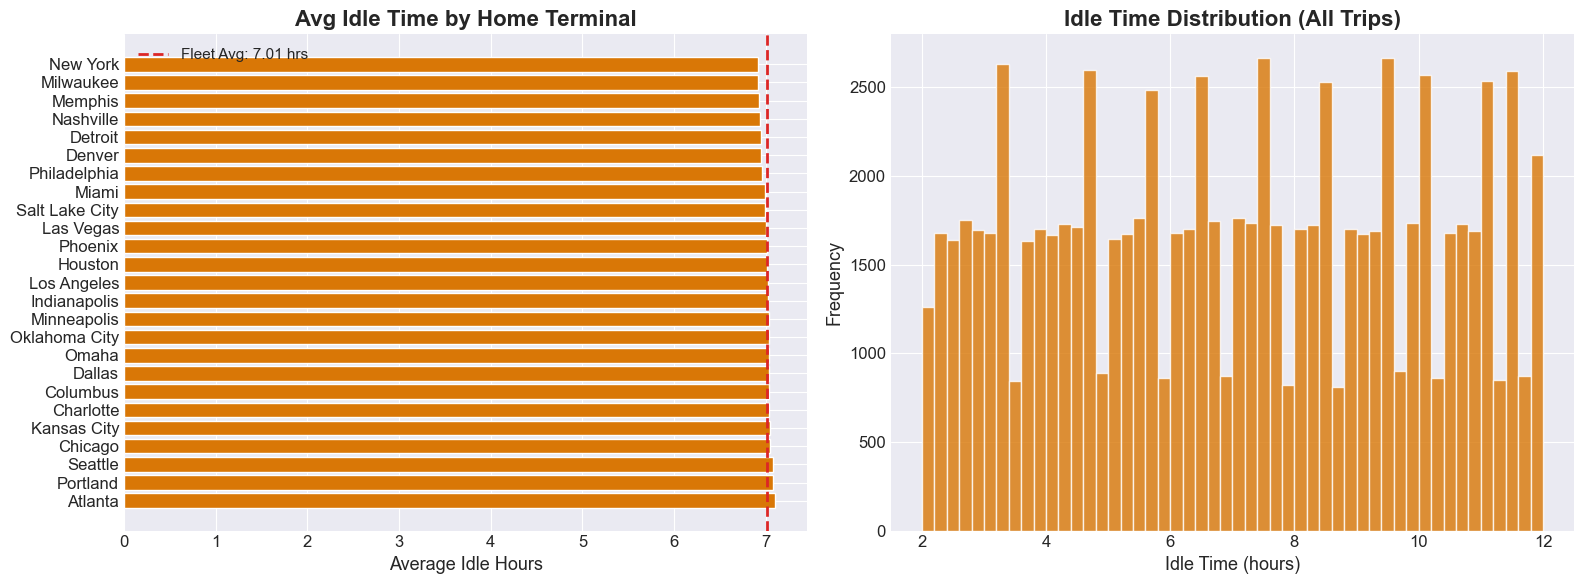

  Total Idle Hours Fleet-wide: 598,791 hours
   Estimated Fuel Wasted (@ 0.8 gal/hr): 479,033 gallons
   Estimated Cost Wasted (@ $4/gal):     $1,916,131


In [13]:
# ============================================================
# Q9: IDLE TIME ANALYSIS BY HOME TERMINAL
# ============================================================
idle_by_terminal = trips.groupby('home_terminal').agg(
    avg_idle=('idle_time_hours', 'mean'),
    total_idle=('idle_time_hours', 'sum'),
    trip_count=('trip_key', 'count')
).reset_index().sort_values('avg_idle', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Avg idle by terminal
axes[0].barh(idle_by_terminal['home_terminal'], idle_by_terminal['avg_idle'], color=COLORS['warning'], edgecolor='white')
axes[0].axvline(trips['idle_time_hours'].mean(), color=COLORS['danger'], linestyle='--', linewidth=2, label=f'Fleet Avg: {trips["idle_time_hours"].mean():.2f} hrs')
axes[0].set_title('Avg Idle Time by Home Terminal', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Average Idle Hours', fontsize=13)
axes[0].legend(fontsize=11)

# Idle time distribution
axes[1].hist(trips['idle_time_hours'].dropna(), bins=50, color=COLORS['warning'], edgecolor='white', alpha=0.8)
axes[1].set_title('Idle Time Distribution (All Trips)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Idle Time (hours)', fontsize=13)
axes[1].set_ylabel('Frequency', fontsize=13)

plt.tight_layout()
plt.show()

total_idle = trips['idle_time_hours'].sum()
print(f'  Total Idle Hours Fleet-wide: {total_idle:,.0f} hours')
print(f'   Estimated Fuel Wasted (@ 0.8 gal/hr): {total_idle * 0.8:,.0f} gallons')
print(f'   Estimated Cost Wasted (@ $4/gal):     ${total_idle * 0.8 * 4:,.0f}')

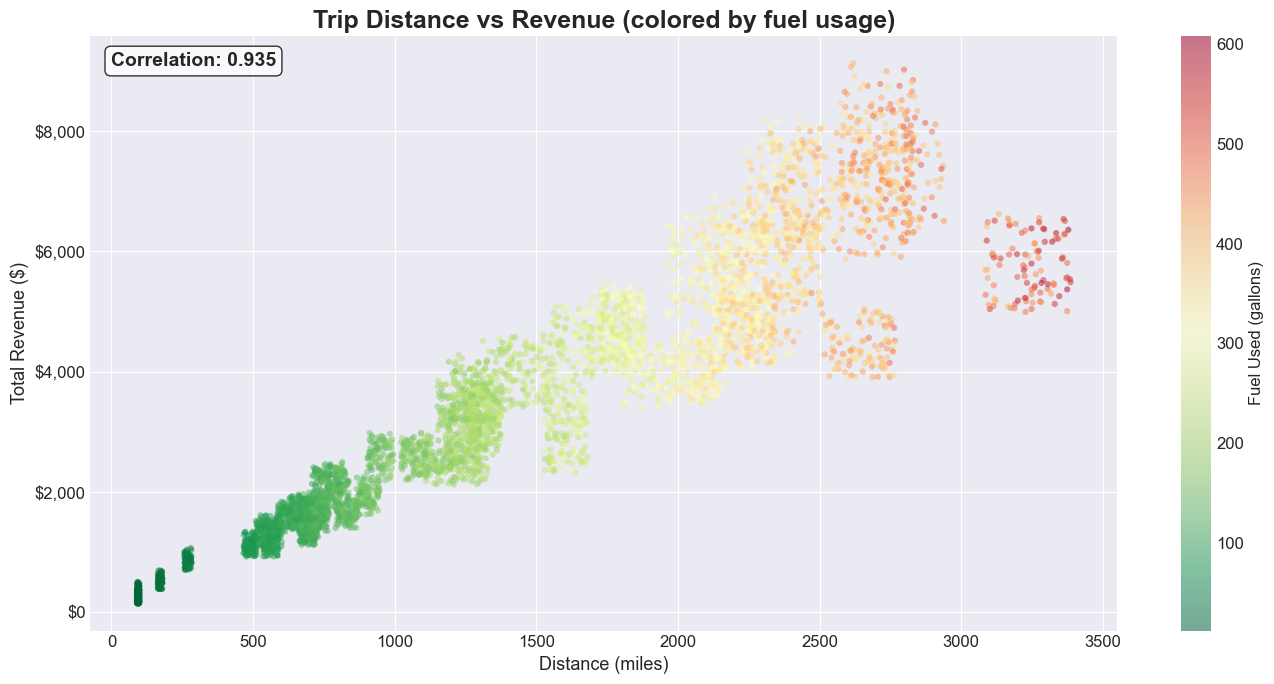

In [14]:
# ============================================================
# Q10: DISTANCE VS REVENUE CORRELATION
# ============================================================
fig, ax = plt.subplots(figsize=(14, 7))
sample = trips.sample(min(5000, len(trips)), random_state=42)
scatter = ax.scatter(sample['actual_distance_miles'], sample['total_revenue'], 
                     c=sample['fuel_gallons_used'], cmap='RdYlGn_r', alpha=0.5, s=20, edgecolors='none')
plt.colorbar(scatter, label='Fuel Used (gallons)', ax=ax)

ax.set_title('Trip Distance vs Revenue (colored by fuel usage)', fontsize=18, fontweight='bold')
ax.set_xlabel('Distance (miles)', fontsize=13)
ax.set_ylabel('Total Revenue ($)', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

corr = trips['actual_distance_miles'].corr(trips['total_revenue'])
ax.text(0.02, 0.95, f'Correlation: {corr:.3f}', transform=ax.transAxes, fontsize=14, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

---
## Phase 4: Fleet & Maintenance Analysis

### Business Questions:
11. What is the total maintenance cost, and how does it trend monthly?
12. How does truck age affect maintenance cost?
13. What is the split between maintenance types (Preventive vs Corrective)?
14. Which trucks have the highest downtime?

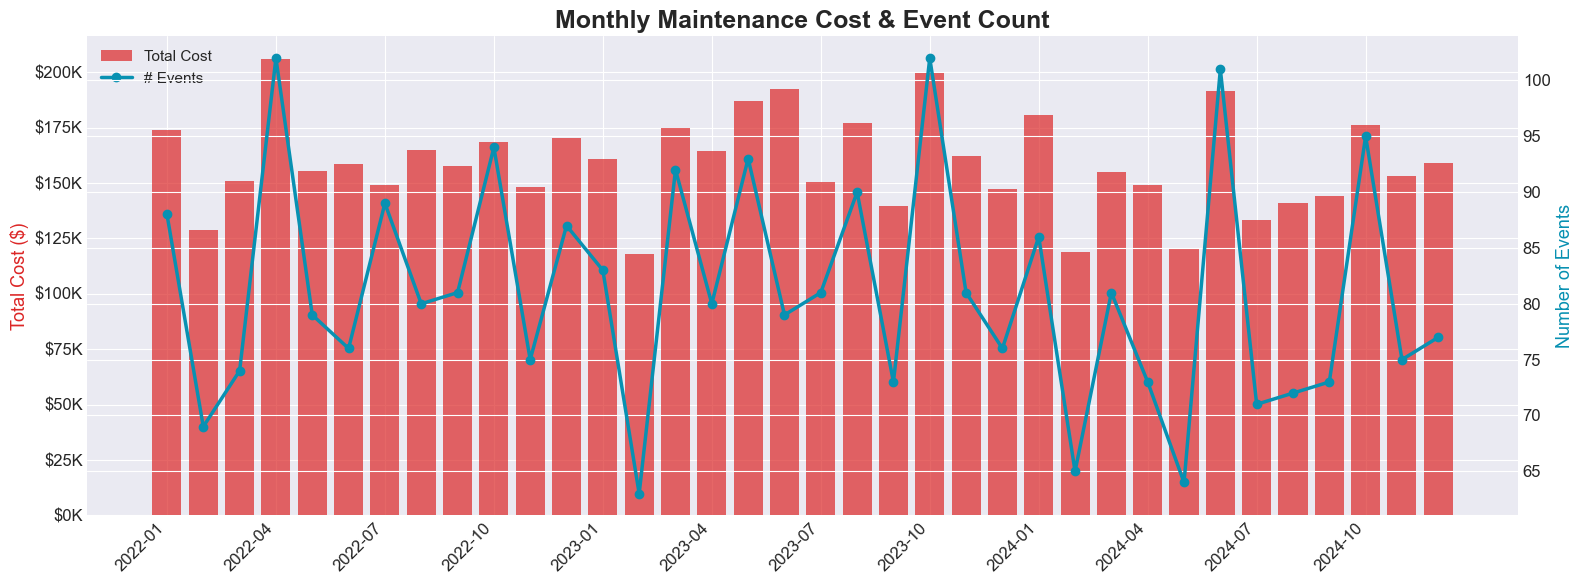

 Total Maintenance Cost:  $5,730,573.28
   Total Events:                   2,920
   Average Cost/Event:      $    1,962.53


In [15]:
# ============================================================
# Q11: MAINTENANCE COST TREND
# ============================================================
monthly_maint = maint.groupby('year_month').agg(
    total_cost=('total_cost', 'sum'),
    event_count=('maintenance_key', 'count'),
    avg_cost=('total_cost', 'mean')
).reset_index().sort_values('year_month')

fig, ax1 = plt.subplots(figsize=(16, 6))
ax1.bar(range(len(monthly_maint)), monthly_maint['total_cost'], color=COLORS['danger'], alpha=0.7, label='Total Cost')
ax1.set_ylabel('Total Cost ($)', fontsize=13, color=COLORS['danger'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

ax2 = ax1.twinx()
ax2.plot(range(len(monthly_maint)), monthly_maint['event_count'], color=COLORS['info'], linewidth=2.5, marker='o', label='# Events')
ax2.set_ylabel('Number of Events', fontsize=13, color=COLORS['info'])

ax1.set_title('Monthly Maintenance Cost & Event Count', fontsize=18, fontweight='bold')
ax1.set_xticks(range(0, len(monthly_maint), 3))
ax1.set_xticklabels(monthly_maint['year_month'].iloc[::3], rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

print(f' Total Maintenance Cost:  ${maint["total_cost"].sum():>12,.2f}')
print(f'   Total Events:            {len(maint):>12,}')
print(f'   Average Cost/Event:      ${maint["total_cost"].mean():>12,.2f}')

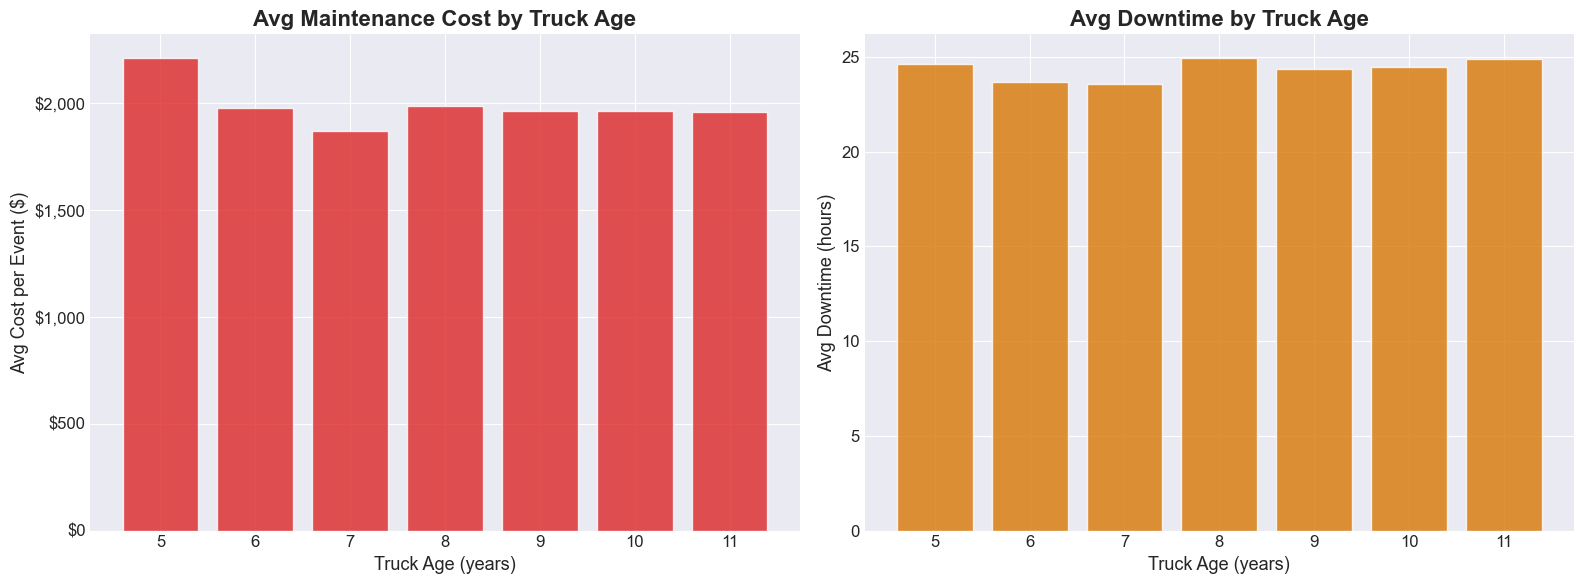

In [16]:
# ============================================================
# Q12: TRUCK AGE VS MAINTENANCE COST
# ============================================================
age_maint = maint.groupby('truck_age_years').agg(
    avg_cost=('total_cost', 'mean'),
    total_cost=('total_cost', 'sum'),
    event_count=('maintenance_key', 'count'),
    avg_downtime=('downtime_hours', 'mean')
).reset_index().sort_values('truck_age_years')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(age_maint['truck_age_years'], age_maint['avg_cost'], color=COLORS['danger'], edgecolor='white', alpha=0.8)
axes[0].set_title('Avg Maintenance Cost by Truck Age', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Truck Age (years)', fontsize=13)
axes[0].set_ylabel('Avg Cost per Event ($)', fontsize=13)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].bar(age_maint['truck_age_years'], age_maint['avg_downtime'], color=COLORS['warning'], edgecolor='white', alpha=0.8)
axes[1].set_title('Avg Downtime by Truck Age', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Truck Age (years)', fontsize=13)
axes[1].set_ylabel('Avg Downtime (hours)', fontsize=13)

plt.tight_layout()
plt.show()

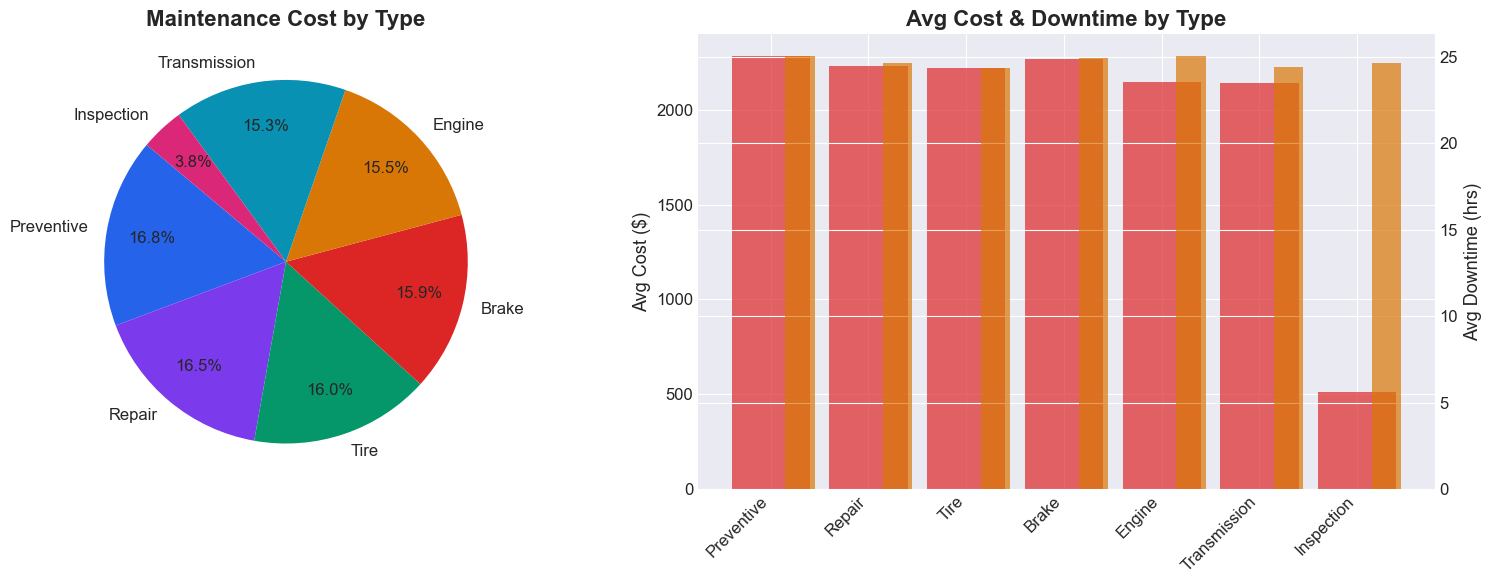


 Maintenance Type Summary:
maintenance_type  total_cost  event_count    avg_cost  avg_downtime
      Preventive   963576.34          422 2283.356256     25.046919
          Repair   945375.44          424 2229.659057     24.653066
            Tire   919413.24          414 2220.804928     24.364976
           Brake   911667.23          402 2267.828930     24.954726
          Engine   890537.88          415 2145.874410     25.051325
    Transmission   879620.87          411 2140.196764     24.415815
      Inspection   220382.28          432  510.144167     24.670602


In [17]:
# ============================================================
# Q13: MAINTENANCE TYPE SPLIT
# ============================================================
maint_type = maint.groupby('maintenance_type').agg(
    total_cost=('total_cost', 'sum'),
    event_count=('maintenance_key', 'count'),
    avg_cost=('total_cost', 'mean'),
    avg_downtime=('downtime_hours', 'mean')
).reset_index().sort_values('total_cost', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].pie(maint_type['total_cost'], labels=maint_type['maintenance_type'],
            autopct='%1.1f%%', colors=COLORS['palette'], startangle=140,
            textprops={'fontsize': 12}, pctdistance=0.75)
axes[0].set_title('Maintenance Cost by Type', fontsize=16, fontweight='bold')

x = range(len(maint_type))
axes[1].bar(x, maint_type['avg_cost'], color=COLORS['danger'], alpha=0.7, label='Avg Cost')
ax2 = axes[1].twinx()
ax2.bar([i+0.3 for i in x], maint_type['avg_downtime'], width=0.3, color=COLORS['warning'], alpha=0.7, label='Avg Downtime')
axes[1].set_xticks(x)
axes[1].set_xticklabels(maint_type['maintenance_type'], rotation=45, ha='right')
axes[1].set_title('Avg Cost & Downtime by Type', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Avg Cost ($)', fontsize=13)
ax2.set_ylabel('Avg Downtime (hrs)', fontsize=13)

plt.tight_layout()
plt.show()

print('\n Maintenance Type Summary:')
print(maint_type.to_string(index=False))

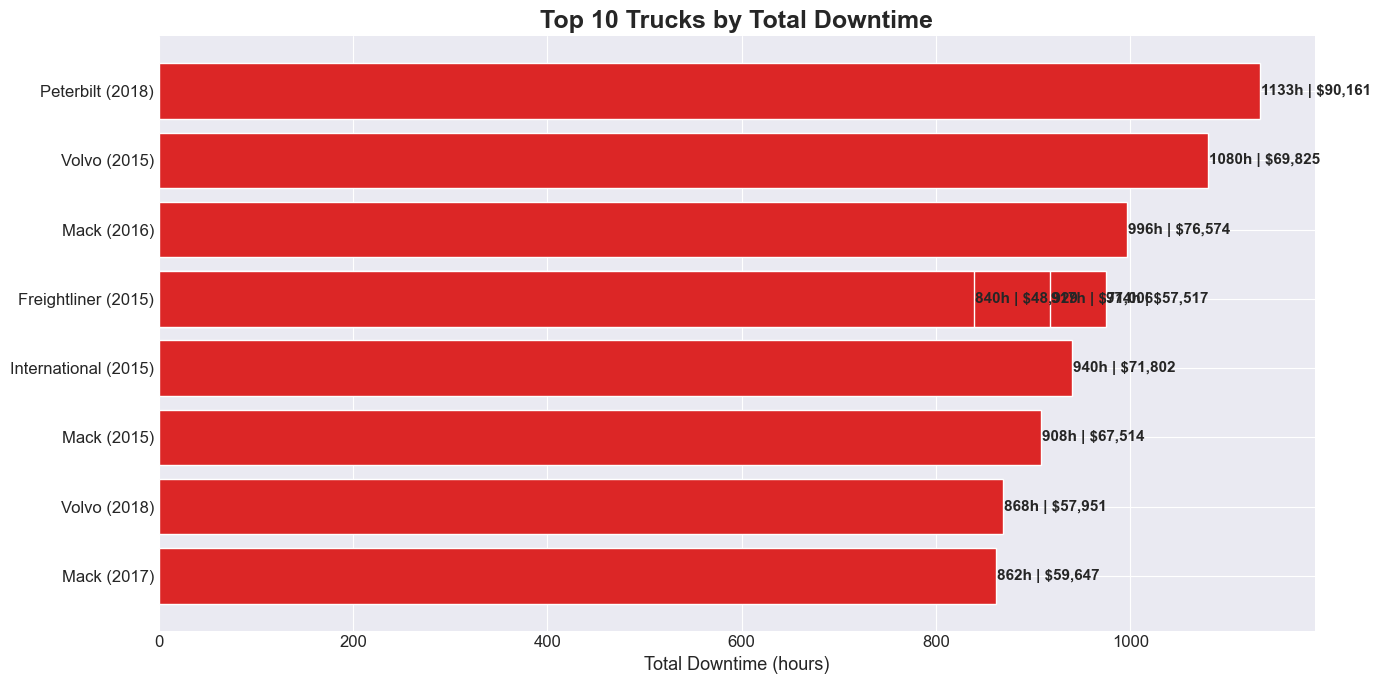

In [18]:
# ============================================================
# Q14: TOP 10 TRUCKS BY DOWNTIME
# ============================================================
truck_downtime = maint.groupby(['truck_key', 'make', 'model_year', 'truck_age_years']).agg(
    total_downtime=('downtime_hours', 'sum'),
    total_cost=('total_cost', 'sum'),
    event_count=('maintenance_key', 'count')
).reset_index().nlargest(10, 'total_downtime')
truck_downtime['label'] = truck_downtime['make'] + ' (' + truck_downtime['model_year'].astype(str) + ')'

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(truck_downtime['label'], truck_downtime['total_downtime'], color=COLORS['danger'], edgecolor='white')
ax.set_title('Top 10 Trucks by Total Downtime', fontsize=18, fontweight='bold')
ax.set_xlabel('Total Downtime (hours)', fontsize=13)
ax.invert_yaxis()

for bar, val, cost in zip(bars, truck_downtime['total_downtime'], truck_downtime['total_cost']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f}h | ${cost:,.0f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Phase 5: Safety Analysis

### Business Questions:
15. What is the total cost of safety incidents, and what are the trends?
16. What are the most common incident types?
17. What percentage of incidents are preventable?
18. Is there a relationship between driver experience and incident frequency?

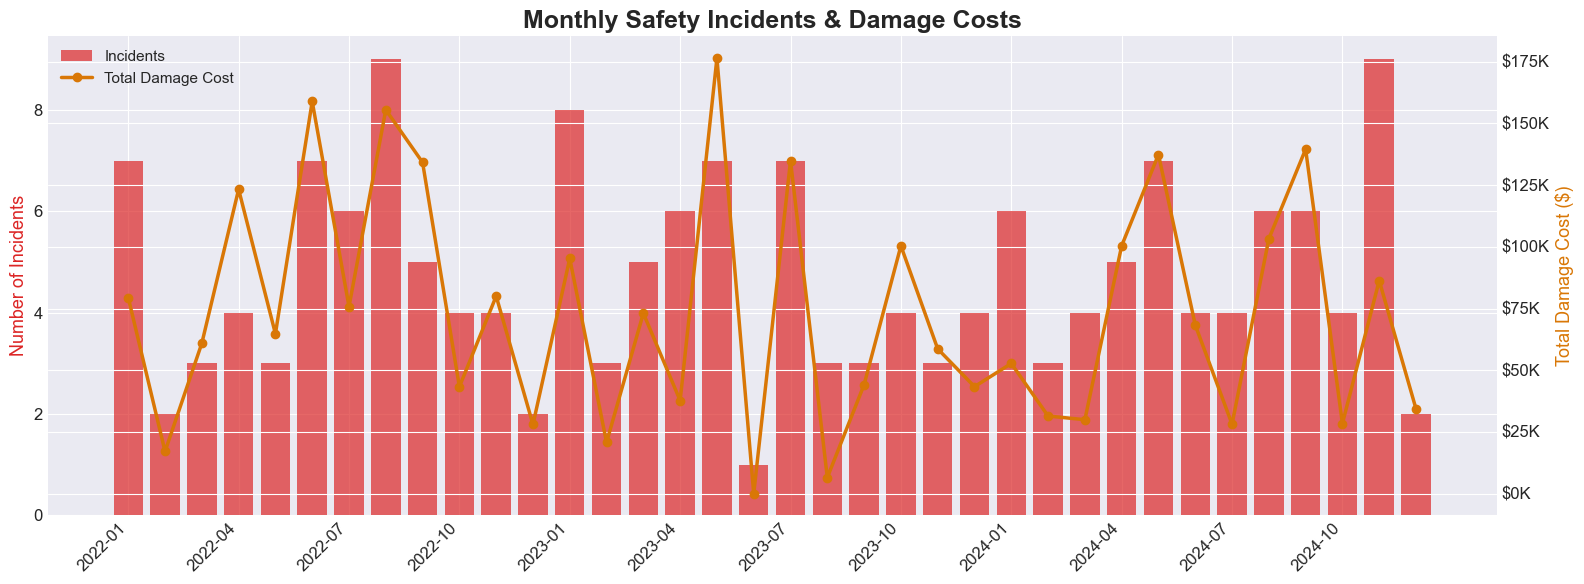

 Total Incidents:             170
   Total Damage Cost:    $2,653,171.82
   Avg Damage/Incident:  $   15,606.89


In [19]:
# ============================================================
# Q15: SAFETY INCIDENT COST TREND
# ============================================================
monthly_safety = safety.groupby('year_month').agg(
    total_damage=('total_damage_cost', 'sum'),
    incident_count=('safety_key', 'count')
).reset_index().sort_values('year_month')

fig, ax1 = plt.subplots(figsize=(16, 6))
ax1.bar(range(len(monthly_safety)), monthly_safety['incident_count'], color=COLORS['danger'], alpha=0.7, label='Incidents')
ax1.set_ylabel('Number of Incidents', fontsize=13, color=COLORS['danger'])

ax2 = ax1.twinx()
ax2.plot(range(len(monthly_safety)), monthly_safety['total_damage'], color=COLORS['warning'], linewidth=2.5, marker='o', label='Total Damage Cost')
ax2.set_ylabel('Total Damage Cost ($)', fontsize=13, color=COLORS['warning'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

ax1.set_title('Monthly Safety Incidents & Damage Costs', fontsize=18, fontweight='bold')
ax1.set_xticks(range(0, len(monthly_safety), 3))
ax1.set_xticklabels(monthly_safety['year_month'].iloc[::3], rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

print(f' Total Incidents:      {len(safety):>10,}')
print(f'   Total Damage Cost:    ${safety["total_damage_cost"].sum():>12,.2f}')
print(f'   Avg Damage/Incident:  ${safety["total_damage_cost"].mean():>12,.2f}')

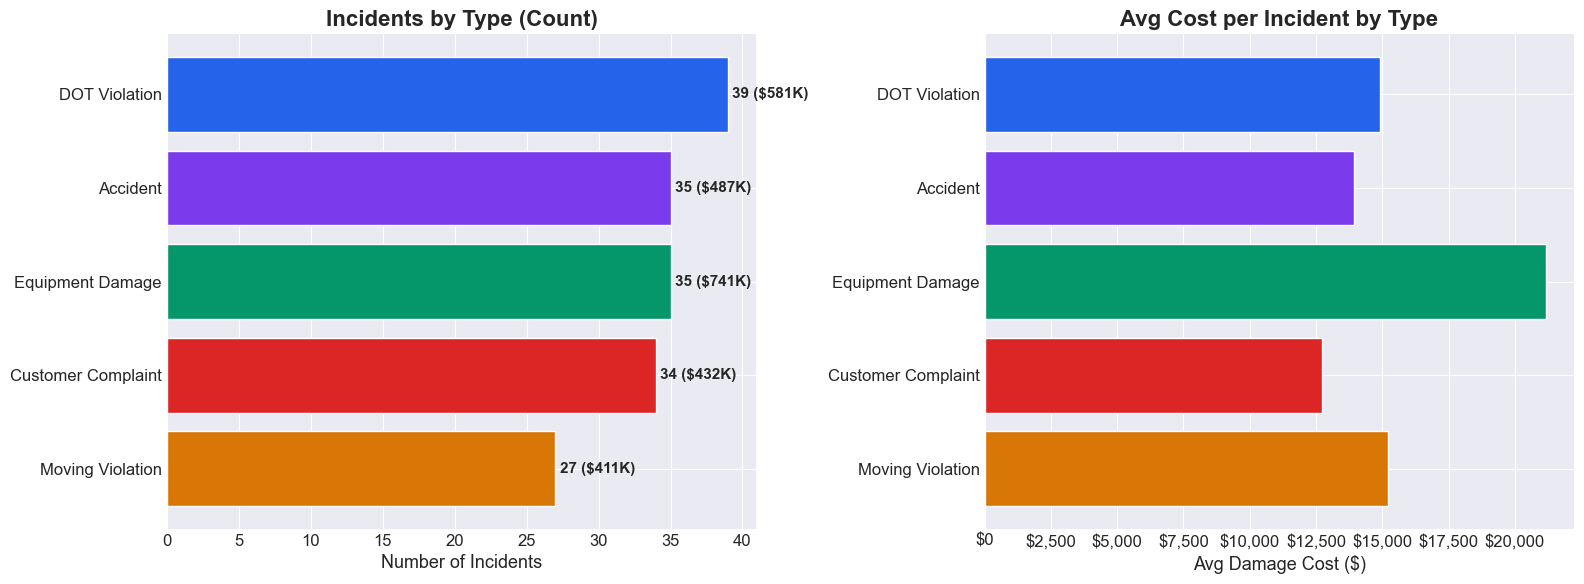

In [20]:
# ============================================================
# Q16: INCIDENT TYPE BREAKDOWN
# ============================================================
incident_type = safety.groupby('incident_type').agg(
    count=('safety_key', 'count'),
    total_cost=('total_damage_cost', 'sum'),
    avg_cost=('total_damage_cost', 'mean')
).reset_index().sort_values('count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(incident_type['incident_type'], incident_type['count'], color=COLORS['palette'][:len(incident_type)], edgecolor='white')
axes[0].set_title('Incidents by Type (Count)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Number of Incidents', fontsize=13)
axes[0].invert_yaxis()
for i, (v, c) in enumerate(zip(incident_type['count'], incident_type['total_cost'])):
    axes[0].text(v + 0.3, i, f'{v} (${c/1e3:.0f}K)', va='center', fontsize=11, fontweight='bold')

axes[1].barh(incident_type['incident_type'], incident_type['avg_cost'], color=COLORS['palette'][:len(incident_type)], edgecolor='white')
axes[1].set_title('Avg Cost per Incident by Type', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Avg Damage Cost ($)', fontsize=13)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

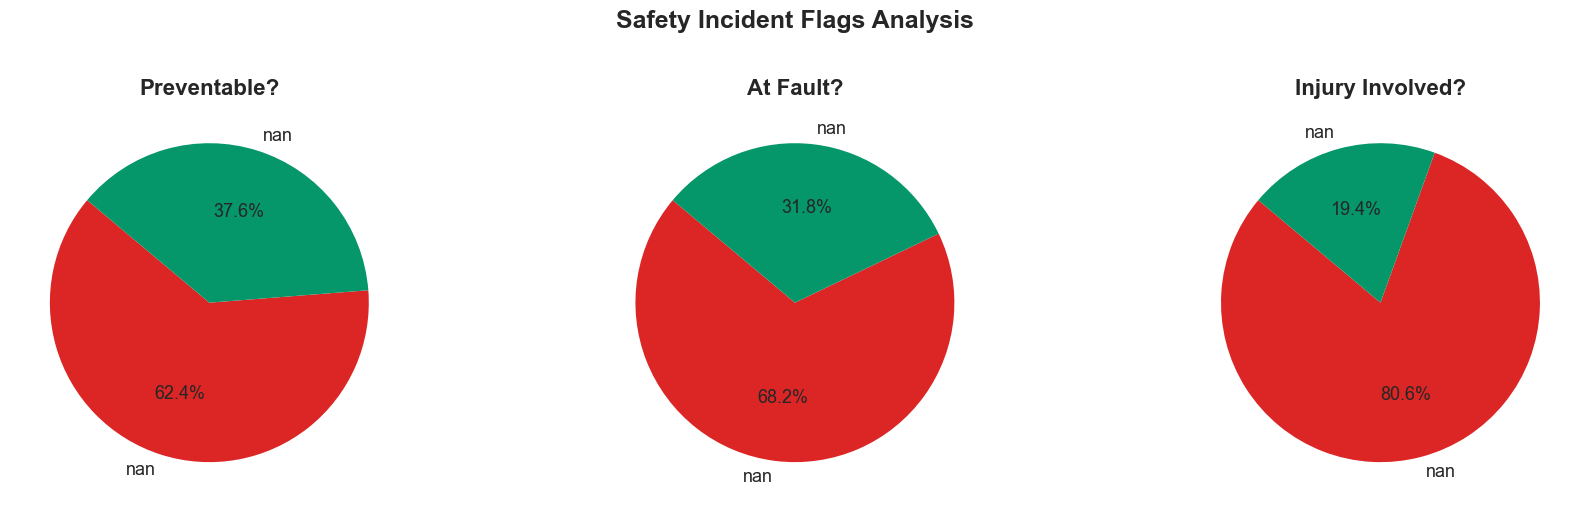

In [21]:
# ============================================================
# Q17: PREVENTABLE INCIDENTS ANALYSIS
# ============================================================
preventable = safety['preventable_flag'].value_counts().reset_index()
preventable.columns = ['preventable', 'count']

at_fault = safety['at_fault_flag'].value_counts().reset_index()
at_fault.columns = ['at_fault', 'count']

injury = safety['injury_flag'].value_counts().reset_index()
injury.columns = ['injury', 'count']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].pie(preventable['count'], labels=preventable['preventable'].map({'True':'Preventable','False':'Non-Preventable'}),
            autopct='%1.1f%%', colors=[COLORS['danger'], COLORS['success']], startangle=140, textprops={'fontsize': 13})
axes[0].set_title('Preventable?', fontsize=16, fontweight='bold')

axes[1].pie(at_fault['count'], labels=at_fault['at_fault'].map({'True':'At Fault','False':'Not At Fault'}),
            autopct='%1.1f%%', colors=[COLORS['danger'], COLORS['success']], startangle=140, textprops={'fontsize': 13})
axes[1].set_title('At Fault?', fontsize=16, fontweight='bold')

axes[2].pie(injury['count'], labels=injury['injury'].map({'True':'Injury','False':'No Injury'}),
            autopct='%1.1f%%', colors=[COLORS['danger'], COLORS['success']], startangle=140, textprops={'fontsize': 13})
axes[2].set_title('Injury Involved?', fontsize=16, fontweight='bold')

plt.suptitle('Safety Incident Flags Analysis', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

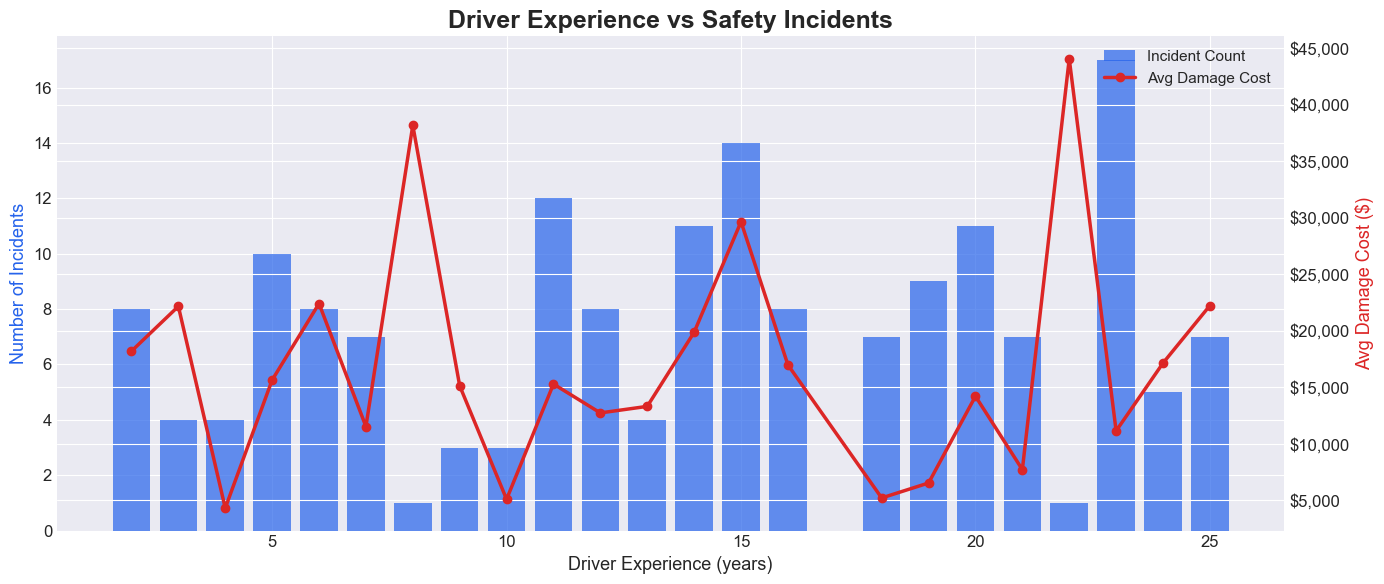

In [22]:
# ============================================================
# Q18: DRIVER EXPERIENCE VS INCIDENTS
# ============================================================
exp_incidents = safety.groupby('years_experience').agg(
    incident_count=('safety_key', 'count'),
    avg_damage=('total_damage_cost', 'mean')
).reset_index().sort_values('years_experience')

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(exp_incidents['years_experience'], exp_incidents['incident_count'], color=COLORS['primary'], alpha=0.7, label='Incident Count')
ax1.set_xlabel('Driver Experience (years)', fontsize=13)
ax1.set_ylabel('Number of Incidents', fontsize=13, color=COLORS['primary'])

ax2 = ax1.twinx()
ax2.plot(exp_incidents['years_experience'], exp_incidents['avg_damage'], color=COLORS['danger'], linewidth=2.5, marker='o', label='Avg Damage Cost')
ax2.set_ylabel('Avg Damage Cost ($)', fontsize=13, color=COLORS['danger'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax1.set_title('Driver Experience vs Safety Incidents', fontsize=18, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

---
## Phase 6: Delivery Performance Analysis

### Business Questions:
19. What is the overall on-time delivery rate?
20. How does on-time rate vary by facility?
21. What is the average detention time, and which facilities are the worst?
22. How does delivery performance trend over time?

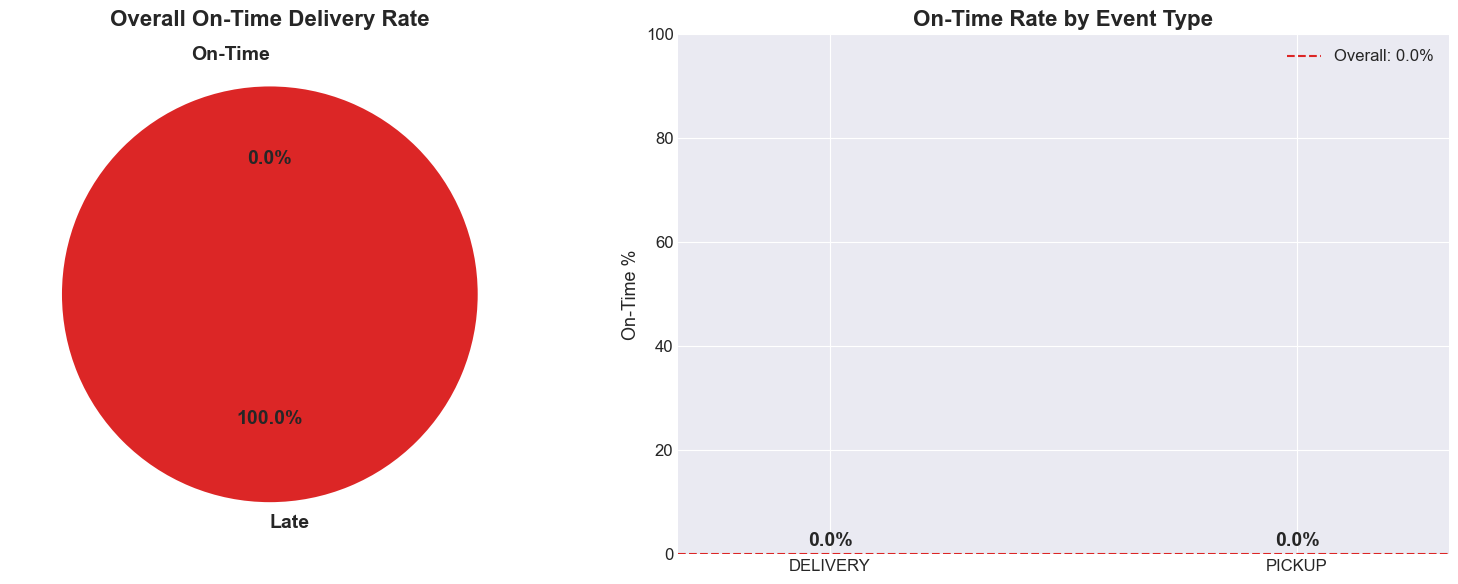

 Total Delivery Events:      170,820
   On-Time Rate:                   0.0%
   Late Rate:                    100.0%


In [23]:
# ============================================================
# Q19: OVERALL ON-TIME DELIVERY RATE
# ============================================================
on_time_rate = (delivery['on_time_flag'] == 'True').mean() * 100
late_rate = 100 - on_time_rate

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gauge-style pie
axes[0].pie([on_time_rate, late_rate], labels=['On-Time', 'Late'],
            autopct='%1.1f%%', colors=[COLORS['success'], COLORS['danger']],
            startangle=90, textprops={'fontsize': 14, 'fontweight': 'bold'},
            explode=[0.05, 0])
axes[0].set_title(f'Overall On-Time Delivery Rate', fontsize=16, fontweight='bold')

# By event type
ot_by_event = delivery.groupby('event_type')['on_time_flag'].apply(lambda x: (x == 'True').mean() * 100).reset_index()
ot_by_event.columns = ['event_type', 'on_time_pct']

bars = axes[1].bar(ot_by_event['event_type'], ot_by_event['on_time_pct'], 
                   color=[COLORS['primary'], COLORS['secondary']], edgecolor='white', width=0.5)
axes[1].set_title('On-Time Rate by Event Type', fontsize=16, fontweight='bold')
axes[1].set_ylabel('On-Time %', fontsize=13)
axes[1].set_ylim(0, 100)
axes[1].axhline(y=on_time_rate, color=COLORS['danger'], linestyle='--', label=f'Overall: {on_time_rate:.1f}%')
axes[1].legend(fontsize=12)

for bar, val in zip(bars, ot_by_event['on_time_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1.5, f'{val:.1f}%', ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f' Total Delivery Events:   {len(delivery):>10,}')
print(f'   On-Time Rate:            {on_time_rate:>10.1f}%')
print(f'   Late Rate:               {late_rate:>10.1f}%')

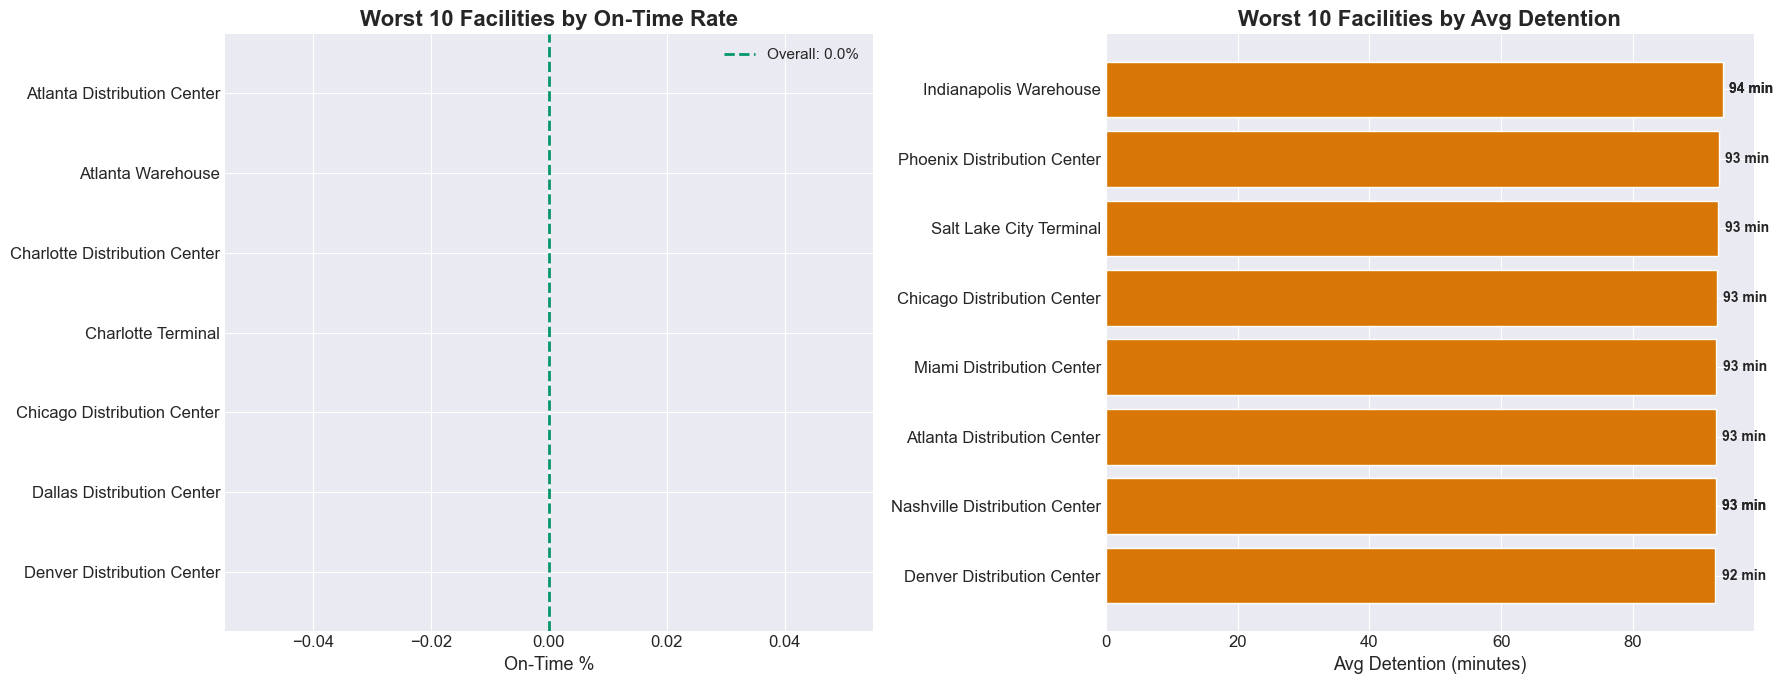

In [24]:
# ============================================================
# Q20 & Q21: FACILITY PERFORMANCE — ON-TIME RATE & DETENTION TIME
# ============================================================
facility_perf = delivery.groupby(['facility_name', 'facility_type']).agg(
    on_time_pct=('on_time_flag', lambda x: (x == 'True').mean() * 100),
    avg_detention=('detention_minutes', 'mean'),
    event_count=('delivery_key', 'count')
).reset_index()

# Top 10 worst facilities by on-time rate (min 100 events)
worst_facilities = facility_perf[facility_perf['event_count'] >= 100].nsmallest(10, 'on_time_pct')

# Top 10 worst by detention
worst_detention = facility_perf[facility_perf['event_count'] >= 100].nlargest(10, 'avg_detention')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(worst_facilities['facility_name'], worst_facilities['on_time_pct'], color=COLORS['danger'], edgecolor='white')
axes[0].axvline(x=on_time_rate, color=COLORS['success'], linestyle='--', linewidth=2, label=f'Overall: {on_time_rate:.1f}%')
axes[0].set_title('Worst 10 Facilities by On-Time Rate', fontsize=16, fontweight='bold')
axes[0].set_xlabel('On-Time %', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].invert_yaxis()

axes[1].barh(worst_detention['facility_name'], worst_detention['avg_detention'], color=COLORS['warning'], edgecolor='white')
axes[1].set_title('Worst 10 Facilities by Avg Detention', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Avg Detention (minutes)', fontsize=13)
axes[1].invert_yaxis()

for bar, val in zip(axes[1].patches, worst_detention['avg_detention']):
    axes[1].text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f} min', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

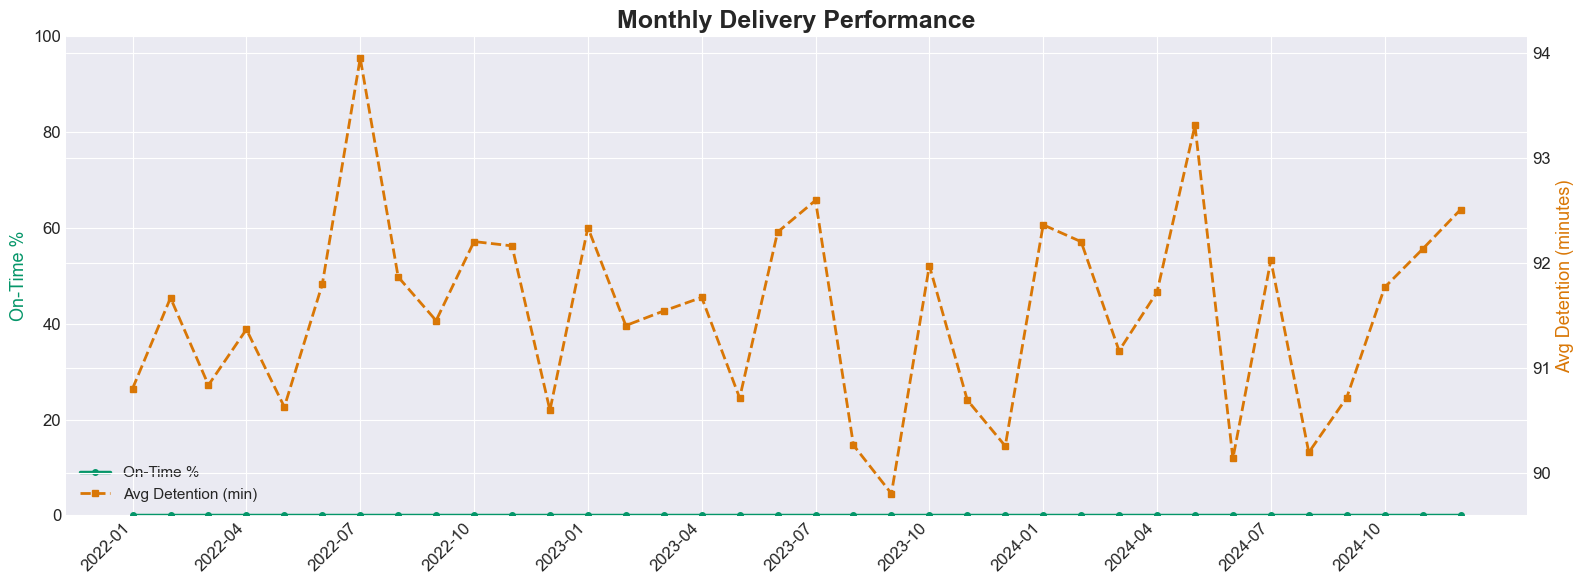

In [25]:
# ============================================================
# Q22: DELIVERY PERFORMANCE TREND OVER TIME
# ============================================================
monthly_delivery = delivery.groupby('year_month').agg(
    on_time_pct=('on_time_flag', lambda x: (x == 'True').mean() * 100),
    avg_detention=('detention_minutes', 'mean'),
    event_count=('delivery_key', 'count')
).reset_index().sort_values('year_month')

fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.plot(range(len(monthly_delivery)), monthly_delivery['on_time_pct'], color=COLORS['success'], linewidth=2.5, marker='o', markersize=4, label='On-Time %')
ax1.set_ylabel('On-Time %', fontsize=13, color=COLORS['success'])
ax1.set_ylim(0, 100)
ax1.fill_between(range(len(monthly_delivery)), monthly_delivery['on_time_pct'], alpha=0.15, color=COLORS['success'])

ax2 = ax1.twinx()
ax2.plot(range(len(monthly_delivery)), monthly_delivery['avg_detention'], color=COLORS['warning'], linewidth=2, linestyle='--', marker='s', markersize=4, label='Avg Detention (min)')
ax2.set_ylabel('Avg Detention (minutes)', fontsize=13, color=COLORS['warning'])

ax1.set_title('Monthly Delivery Performance', fontsize=18, fontweight='bold')
ax1.set_xticks(range(0, len(monthly_delivery), 3))
ax1.set_xticklabels(monthly_delivery['year_month'].iloc[::3], rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=11)

plt.tight_layout()
plt.show()

---
## Phase 7: Driver Performance Analysis

### Business Questions:
23. Who are the top 10 revenue-generating drivers?
24. How does driver experience correlate with revenue per trip?
25. Which drivers are the most fuel-efficient?
26. Driver performance scorecard — Revenue, Efficiency, Safety combined

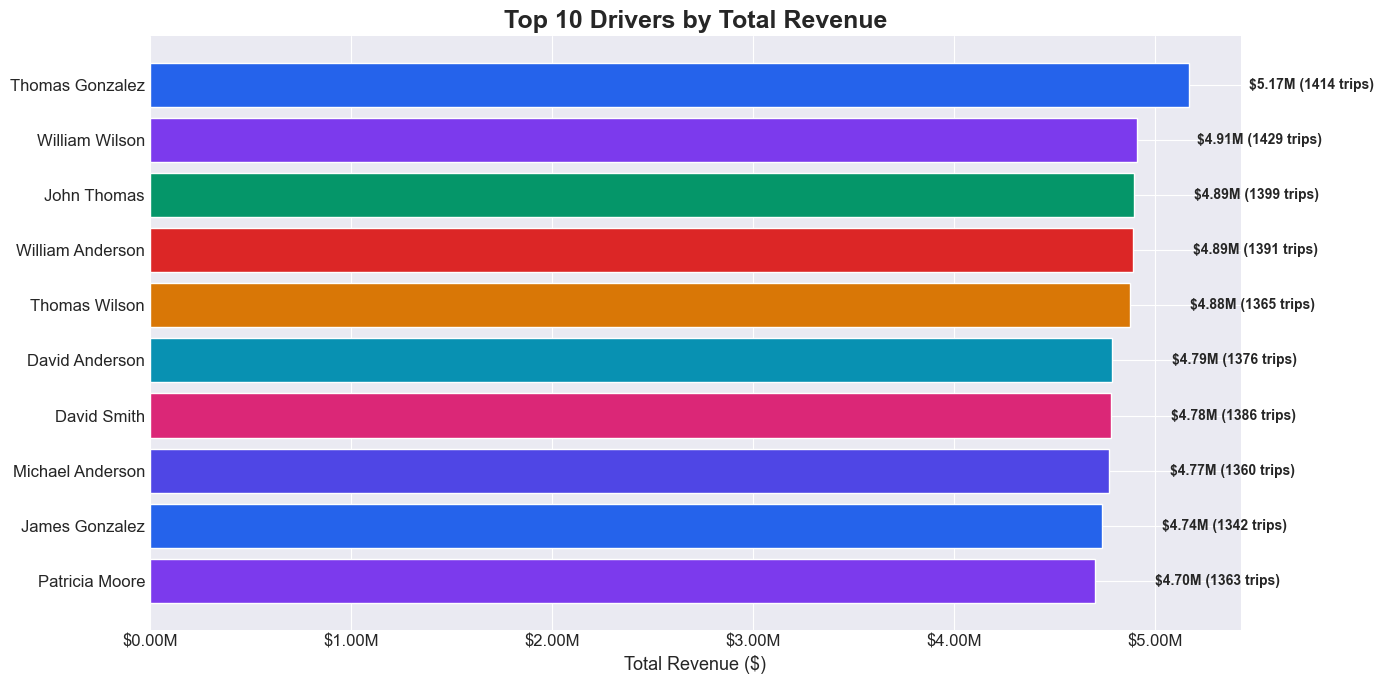

In [26]:
# ============================================================
# Q23: TOP 10 DRIVERS BY REVENUE
# ============================================================
driver_rev = trips.groupby('full_name').agg(
    total_revenue=('total_revenue', 'sum'),
    trip_count=('trip_key', 'count'),
    avg_revenue=('total_revenue', 'mean'),
    avg_mpg=('average_mpg', 'mean')
).reset_index()

top_drivers = driver_rev.nlargest(10, 'total_revenue')

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top_drivers['full_name'], top_drivers['total_revenue'], color=COLORS['palette'][:10], edgecolor='white')
ax.set_title('Top 10 Drivers by Total Revenue', fontsize=18, fontweight='bold')
ax.set_xlabel('Total Revenue ($)', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.2f}M'))
ax.invert_yaxis()

for bar, val, cnt in zip(bars, top_drivers['total_revenue'], top_drivers['trip_count']):
    ax.text(val + total_revenue * 0.001, bar.get_y() + bar.get_height()/2, f'${val/1e6:.2f}M ({cnt} trips)', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

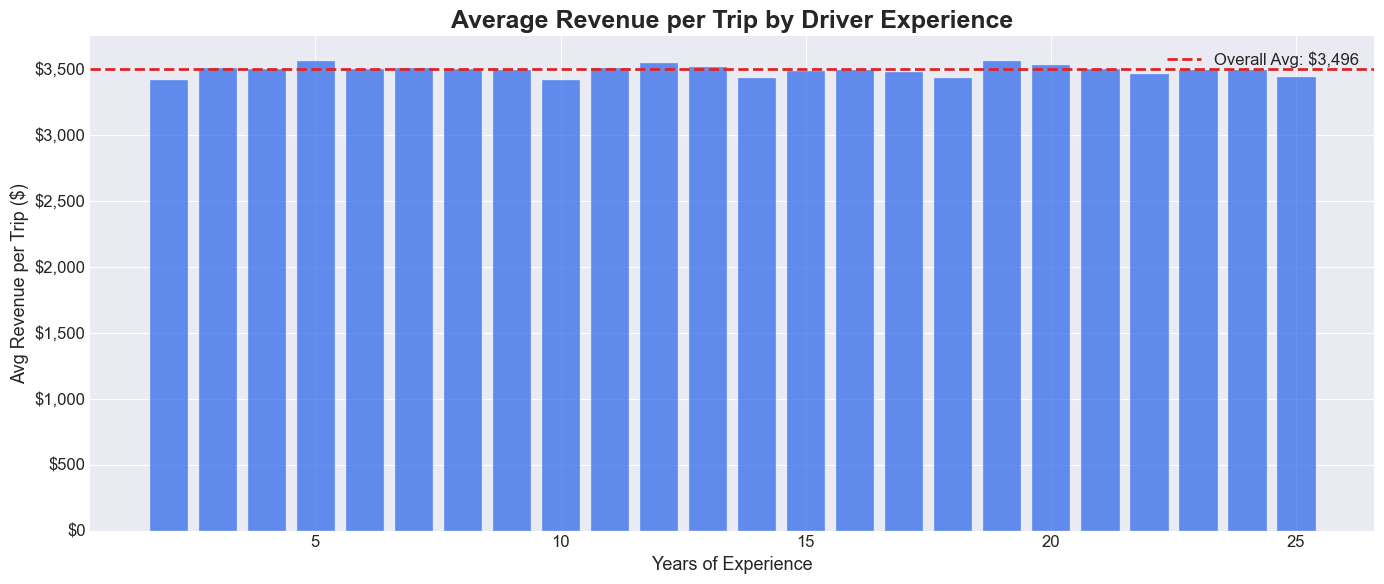

In [27]:
# ============================================================
# Q24: EXPERIENCE VS REVENUE PER TRIP
# ============================================================
exp_rev = trips.groupby('years_experience').agg(
    avg_revenue=('total_revenue', 'mean'),
    avg_distance=('actual_distance_miles', 'mean'),
    trip_count=('trip_key', 'count')
).reset_index().sort_values('years_experience')

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(exp_rev['years_experience'], exp_rev['avg_revenue'], color=COLORS['primary'], alpha=0.7, edgecolor='white')
ax.set_title('Average Revenue per Trip by Driver Experience', fontsize=18, fontweight='bold')
ax.set_xlabel('Years of Experience', fontsize=13)
ax.set_ylabel('Avg Revenue per Trip ($)', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.axhline(y=avg_revenue, color=COLORS['danger'], linestyle='--', linewidth=2, label=f'Overall Avg: ${avg_revenue:,.0f}')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

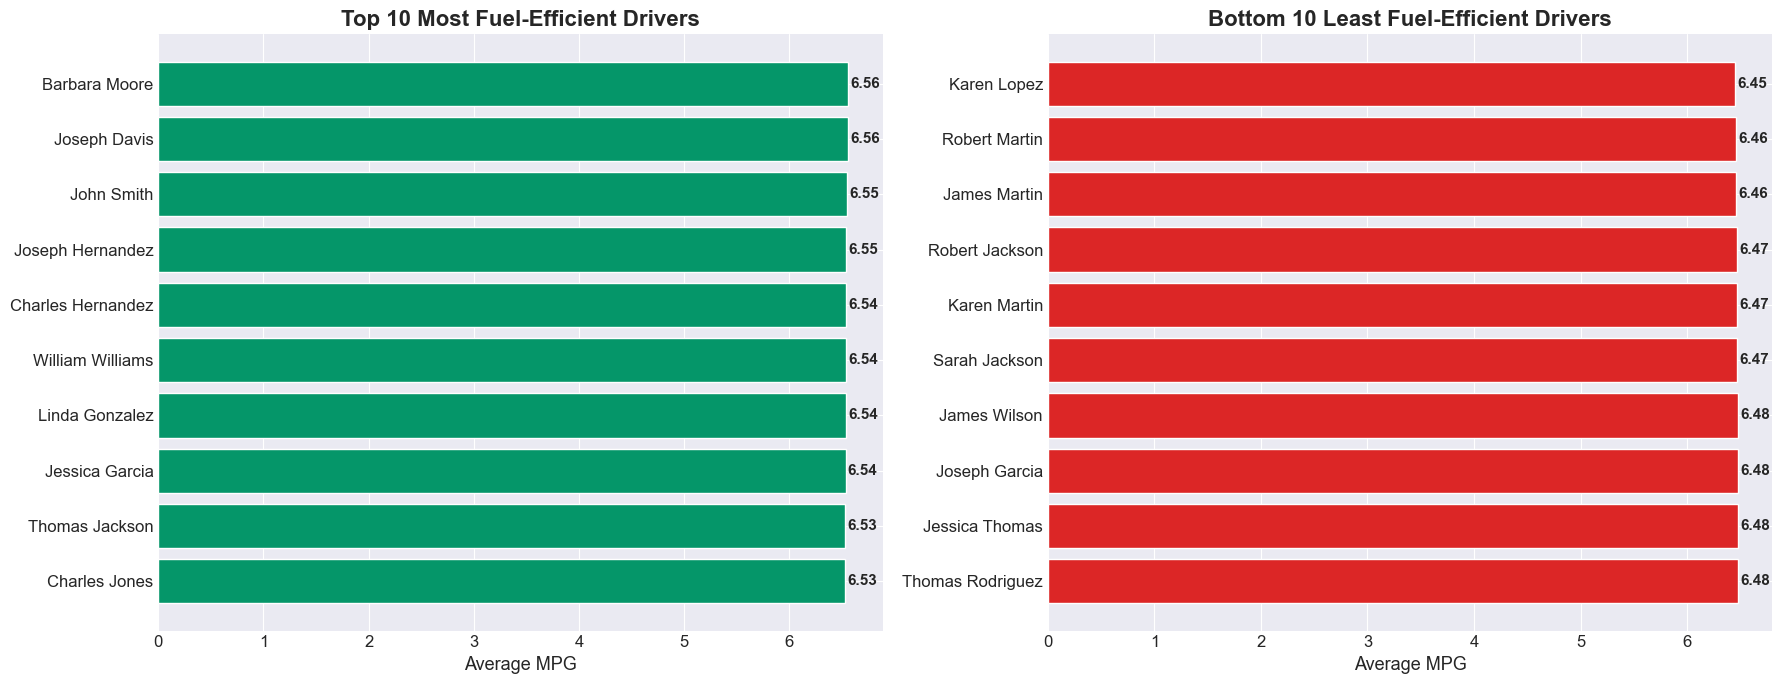

In [28]:
# ============================================================
# Q25: MOST FUEL-EFFICIENT DRIVERS (Top & Bottom 10)
# ============================================================
driver_mpg = trips.groupby('full_name').agg(
    avg_mpg=('average_mpg', 'mean'),
    trip_count=('trip_key', 'count'),
    total_fuel=('fuel_gallons_used', 'sum')
).reset_index()
driver_mpg = driver_mpg[driver_mpg['trip_count'] >= 50]  # min 50 trips

top_mpg = driver_mpg.nlargest(10, 'avg_mpg')
bottom_mpg = driver_mpg.nsmallest(10, 'avg_mpg')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(top_mpg['full_name'], top_mpg['avg_mpg'], color=COLORS['success'], edgecolor='white')
axes[0].set_title('Top 10 Most Fuel-Efficient Drivers', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Average MPG', fontsize=13)
axes[0].invert_yaxis()
for bar, val in zip(axes[0].patches, top_mpg['avg_mpg']):
    axes[0].text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=11, fontweight='bold')

axes[1].barh(bottom_mpg['full_name'], bottom_mpg['avg_mpg'], color=COLORS['danger'], edgecolor='white')
axes[1].set_title('Bottom 10 Least Fuel-Efficient Drivers', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Average MPG', fontsize=13)
axes[1].invert_yaxis()
for bar, val in zip(axes[1].patches, bottom_mpg['avg_mpg']):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

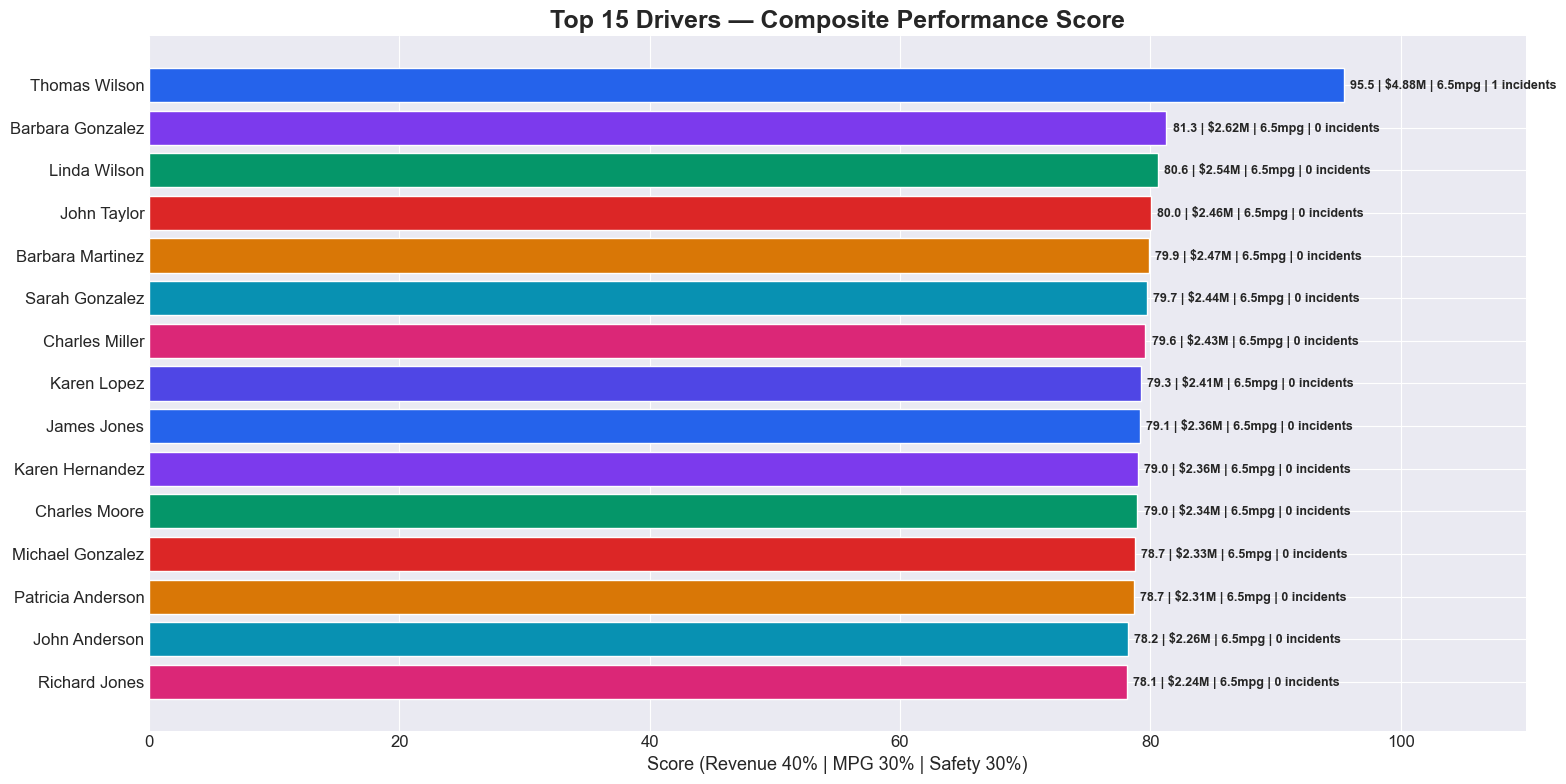

In [29]:
# ============================================================
# Q26: DRIVER PERFORMANCE SCORECARD (Top 15)
# ============================================================
# Build composite scores
driver_score = trips.groupby(['full_name','years_experience']).agg(
    total_revenue=('total_revenue', 'sum'),
    trip_count=('trip_key', 'count'),
    avg_mpg=('average_mpg', 'mean'),
    avg_revenue=('total_revenue', 'mean'),
    total_distance=('actual_distance_miles', 'sum')
).reset_index()

# Add safety record
safety_count = safety.groupby('full_name')['safety_key'].count().reset_index()
safety_count.columns = ['full_name', 'incident_count']
driver_score = driver_score.merge(safety_count, on='full_name', how='left')
driver_score['incident_count'] = driver_score['incident_count'].fillna(0).astype(int)

# Normalize scores (0-100)
driver_score['rev_score'] = (driver_score['total_revenue'] / driver_score['total_revenue'].max()) * 100
driver_score['mpg_score'] = (driver_score['avg_mpg'] / driver_score['avg_mpg'].max()) * 100
driver_score['safety_score'] = 100 - (driver_score['incident_count'] / driver_score['incident_count'].max()) * 100
driver_score['composite'] = (driver_score['rev_score'] * 0.4 + driver_score['mpg_score'] * 0.3 + driver_score['safety_score'] * 0.3)

top_performers = driver_score.nlargest(15, 'composite')[['full_name','years_experience','total_revenue','trip_count','avg_mpg','incident_count','composite']]

fig, ax = plt.subplots(figsize=(16, 8))
bars = ax.barh(top_performers['full_name'], top_performers['composite'], color=COLORS['palette'][:15], edgecolor='white')
ax.set_title('Top 15 Drivers — Composite Performance Score', fontsize=18, fontweight='bold')
ax.set_xlabel('Score (Revenue 40% | MPG 30% | Safety 30%)', fontsize=13)
ax.invert_yaxis()
ax.set_xlim(0, 110)

for bar, row in zip(bars, top_performers.itertuples()):
    ax.text(row.composite + 0.5, bar.get_y() + bar.get_height()/2,
            f'{row.composite:.1f} | ${row.total_revenue/1e6:.2f}M | {row.avg_mpg:.1f}mpg | {row.incident_count} incidents',
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Phase 8: Executive Summary & KPIs

In [30]:
# ============================================================
# EXECUTIVE SUMMARY KPIs
# ============================================================
total_fuel_cost = fuel['total_cost'].sum()
total_maint_cost = maint['total_cost'].sum()
total_safety_cost = safety['total_damage_cost'].sum()
gross_profit = total_revenue - total_fuel_cost
net_operating = gross_profit - total_maint_cost - total_safety_cost

print('=' * 65)
print('   EXECUTIVE SUMMARY — LOGISTICS DATA WAREHOUSE')
print('=' * 65)
print()
print('   FINANCIAL KPIs')
print(f'     Total Revenue:              ${total_revenue:>15,.2f}')
print(f'     Total Fuel Cost:            ${total_fuel_cost:>15,.2f}')
print(f'     Gross Profit:               ${gross_profit:>15,.2f}')
print(f'     Gross Margin:               {gross_profit/total_revenue*100:>14.1f}%')
print(f'     Maintenance Cost:           ${total_maint_cost:>15,.2f}')
print(f'     Safety Incident Cost:       ${total_safety_cost:>15,.2f}')
print(f'     Net Operating Income:       ${net_operating:>15,.2f}')
print(f'     Net Margin:                 {net_operating/total_revenue*100:>14.1f}%')
print()
print('   OPERATIONAL KPIs')
print(f'     Total Trips:                {total_trips:>15,}')
print(f'     Avg Revenue per Trip:       ${avg_revenue:>15,.2f}')
print(f'     Fleet Size (Trucks):        {len(dim_truck):>15,}')
print(f'     Active Drivers:             {len(dim_driver):>15,}')
print(f'     Avg Trip Distance:          {trips["actual_distance_miles"].mean():>15,.0f} mi')
print(f'     Avg Trip Duration:          {trips["actual_duration_hours"].mean():>15,.1f} hrs')
print(f'     Fleet Avg MPG:              {trips["average_mpg"].mean():>15,.2f}')
print()
print('   DELIVERY KPIs')
print(f'     Total Delivery Events:      {len(delivery):>15,}')
print(f'     On-Time Delivery Rate:      {on_time_rate:>14.1f}%')
print(f'     Avg Detention Time:         {delivery["detention_minutes"].mean():>14.0f} min')
print()
print('   FLEET HEALTH KPIs')
print(f'     Maintenance Events:         {len(maint):>15,}')
print(f'     Avg Maintenance Cost:       ${maint["total_cost"].mean():>15,.2f}')
print(f'     Avg Downtime/Event:         {maint["downtime_hours"].mean():>14.1f} hrs')
print()
print('   SAFETY KPIs')
print(f'     Total Incidents:            {len(safety):>15,}')
print(f'     Incident Rate per 1K trips: {len(safety)/total_trips*1000:>14.1f}')
print(f'     Avg Damage per Incident:    ${safety["total_damage_cost"].mean():>15,.2f}')
print(f'     Preventable Rate:           {(safety["preventable_flag"]=="True").mean()*100:>14.1f}%')
print()
print('=' * 65)

   EXECUTIVE SUMMARY — LOGISTICS DATA WAREHOUSE

   FINANCIAL KPIs
     Total Revenue:              $ 298,621,428.94
     Total Fuel Cost:            $  95,592,992.04
     Gross Profit:               $ 203,028,436.90
     Gross Margin:                         68.0%
     Maintenance Cost:           $   5,730,573.28
     Safety Incident Cost:       $   2,653,171.82
     Net Operating Income:       $ 194,644,691.80
     Net Margin:                           65.2%

   OPERATIONAL KPIs
     Total Trips:                         85,410
     Avg Revenue per Trip:       $       3,496.33
     Fleet Size (Trucks):                    120
     Active Drivers:                         150
     Avg Trip Distance:                    1,430 mi
     Avg Trip Duration:                     25.0 hrs
     Fleet Avg MPG:                         6.50

   DELIVERY KPIs
     Total Delivery Events:              170,820
     On-Time Delivery Rate:                 0.0%
     Avg Detention Time:                     92

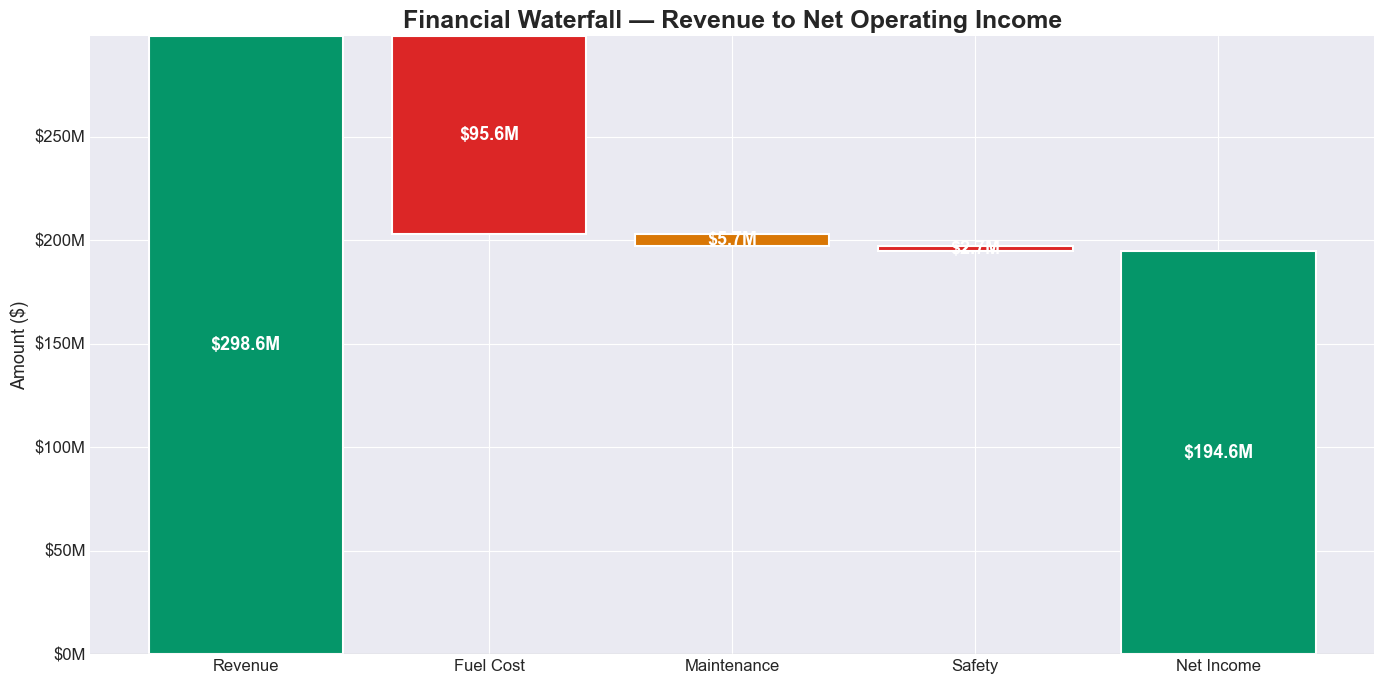

In [31]:
# ============================================================
# FINANCIAL WATERFALL CHART
# ============================================================
categories = ['Revenue', 'Fuel Cost', 'Maintenance', 'Safety', 'Net Income']
values = [total_revenue, -total_fuel_cost, -total_maint_cost, -total_safety_cost, net_operating]
colors = [COLORS['success'], COLORS['danger'], COLORS['warning'], COLORS['danger'], 
          COLORS['success'] if net_operating > 0 else COLORS['danger']]

cumulative = [0]
for v in values[:-1]:
    cumulative.append(cumulative[-1] + v)

fig, ax = plt.subplots(figsize=(14, 7))

for i, (cat, val, cum, col) in enumerate(zip(categories, values, cumulative, colors)):
    if i == len(categories) - 1:  # Net income bar starts from 0
        ax.bar(cat, val, color=col, edgecolor='white', linewidth=1.5)
    else:
        ax.bar(cat, val, bottom=cum, color=col, edgecolor='white', linewidth=1.5)
    
    label_y = cum + val/2 if i < len(categories) - 1 else val/2
    ax.text(i, label_y, f'${abs(val)/1e6:.1f}M', ha='center', va='center',
            fontsize=13, fontweight='bold', color='white')

ax.set_title('Financial Waterfall — Revenue to Net Operating Income', fontsize=18, fontweight='bold')
ax.set_ylabel('Amount ($)', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.axhline(y=0, color='gray', linewidth=0.8)

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# YEARLY COMPARISON HEATMAP
# ============================================================
yearly_kpis = trips.groupby('year').agg(
    revenue=('total_revenue', 'sum'),
    trips=('trip_key', 'count'),
    avg_rev=('total_revenue', 'mean'),
    avg_distance=('actual_distance_miles', 'mean'),
    avg_mpg=('average_mpg', 'mean'),
    avg_idle=('idle_time_hours', 'mean')
).reset_index()

yearly_fuel = fuel.groupby('year')['total_cost'].sum().reset_index()
yearly_fuel.columns = ['year', 'fuel_cost']

yearly_maint_data = maint.groupby('year')['total_cost'].sum().reset_index()
yearly_maint_data.columns = ['year', 'maint_cost']

yearly = yearly_kpis.merge(yearly_fuel, on='year', how='left').merge(yearly_maint_data, on='year', how='left')
yearly['margin_pct'] = ((yearly['revenue'] - yearly['fuel_cost']) / yearly['revenue'] * 100).round(1)

print(' Year-over-Year Comparison:')
print(yearly.to_string(index=False))
print()

# Growth rates
if len(yearly) > 1:
    for col in ['revenue', 'trips', 'fuel_cost']:
        yearly[f'{col}_growth'] = yearly[col].pct_change() * 100
    print(' Year-over-Year Growth Rates:')
    growth_cols = [c for c in yearly.columns if 'growth' in c]
    print(yearly[['year'] + growth_cols].dropna().to_string(index=False))

 Year-over-Year Comparison:
 year     revenue  trips     avg_rev  avg_distance  avg_mpg  avg_idle   fuel_cost  maint_cost  margin_pct
 2022 99922318.92  28589 3495.131656   1430.174927 6.498946  7.025930 34345178.89  1931926.19        65.6
 2023 98908237.80  28165 3511.742865   1437.846015 6.497521  7.002350 31073119.57  1974808.56        68.6
 2024 99790872.22  28656 3482.372704   1422.913072 6.507847  7.003961 30081424.68  1823838.53        69.9

 Year-over-Year Growth Rates:
 year  revenue_growth  trips_growth  fuel_cost_growth
 2023       -1.014869     -1.483088         -9.526983
 2024        0.892377      1.743298         -3.191488


In [33]:
# ============================================================
# CLOSE CONNECTION
# ============================================================
conn.close()
print(' Database connection closed.')
print('\n Analysis complete! All 26 business questions answered.')

 Database connection closed.

 Analysis complete! All 26 business questions answered.
